#  Small-scale snow cover variability and its effect on ground surface temperatures in West Greenland

Sofia Rosa Bauriedl

Models implemented for the paper: "Small-scale snow cover variability and its effect on ground surface temperatures in West Greenland"

To quantify relationships between snowpack properties, topography and ground surface temperature, we
developed Bayesian regression models. As the response variable, we used mean ground surface temperature from
Febrary to March 2024.
Prior to model fitting, we transformed and rescaled all predictors to improve interpretability and numerical stability. 
We tested multiple models to predict ground surface temperature, using different combinations
f snow depth, snow density, and topographic predictors (slope, elevation, and aspect). We conducted prior
predictive checks to confirm that priors resulted in plausible predicted ground surface temperature
ranges.
We obtained approximate samples from the posterior distribution for each model using the default configuration of the No-U-Turn sampler of (Hoffman and Gelman 2011). We also retained point-wise log-likelihood values to enable model comparison. 
To evaluate model performance and select the most informative predictors, we compared all
models using leave-one-out cross-validation (LOO).


In [1]:
# system
import os
import os.path as path

# data
import numpy as np
import pandas as pd

# stats / inference
import pymc as pm
import bambi as bmb
from bambi.priors import Prior
import arviz as az
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import arviz as az

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [164]:
df = pd.read_csv("sensor_data.csv")
model_vars = ['snow_depth', 'bulk_density', 'T_surface', 'topography', 'vegetation', 'TMS_ID', 'elevation', 'aspect', 'slope','soil_moisture']  
df = df.dropna(subset=model_vars).copy()


The columns *tomst_id*, *sr_nr*, *TMS_ID*, *Transect*, *Plot*, *Lat* and *Lon* identify the individual Temperature-Moisture-Sensor (TMS/Tomst) and its associated sampling location within the study design. 

Topographic characteristics of the sensor locations include *slope* (°), *aspect* (°), and *elevation* (m a.s.l.), which were derived from a digital terrain model. Each sensor location was additionally assigned to a categorical *topography* class based on geomorphological position (not used on this analysis).

Vegetation conditions at each sensor location were determined from field vegetation adn moisture surveys and classified into four vegetation categories represented by the variable *vegetation*.

Snow properties were derived from SnowMicroPen measurements collected in April 2024. Multiple SMP profiles were obtained around each sensor. *snow_depth* represents the mean snow depth (m) and *bulk_density* represents the mean snow density (dimensionless metric proportional to volumetric ice content), associated with each sensor location.

*T_surface* represents the mean ground surface temperature measured by the sensors during February and March 2024. 
*soil_moisture* corresponds to the last available volumetric soil moisture measurement recorded before soil freeze-up. 

In [165]:
df

,tomst_id,sr_nr,TMS_ID,Transect,Plot,Lat,Lon,vegetation,topography,slope,elevation,aspect,snow_depth,bulk_density,T_surface,tms_id,soil_moisture
0,6,94231022,A,3,1,69.278881,-53.479375,dry tundra,footslope,2.66,88.00,6.63,0.81,0.307,-5.303336,94231022,0.270004
1,7,94231023,B,3,2,69.278717,-53.477737,dry shrub,footslope,4.90,90.29,269.73,0.59,0.297,-3.170914,94231023,0.245999
2,8,94231024,C,3,2,69.278723,-53.477548,moist tundra,plain,0.47,90.58,261.64,0.74,0.286,-4.272328,94231024,0.493143
3,15,94231031,E,3,4,69.278654,-53.474111,dry tundra,footslope,4.25,106.26,198.99,0.36,0.272,-9.896081,94231031,0.230189
4,16,94231032,H,1,1,69.267720,-53.466919,moist tundra,footslope,3.27,86.50,320.75,0.57,0.289,-1.628434,94231032,0.599245
5,19,94231035,I,1,2,69.268028,-53.466093,moist tundra,footslope,2.06,88.11,285.21,0.68,0.295,-3.871153,94231035,0.548203
6,20,94231036,J,1,2,69.267811,-53.466177,moist shrub,plain,0.68,87.93,146.00,0.48,0.289,-5.077051,94231036,0.422474
7,23,94231039,K,1,3,69.268148,-53.464995,dry shrub,footslope,2.75,90.99,313.23,0.59,0.286,-4.861922,94231039,0.210919
8,25,94231041,L,1,4,69.268748,-53.462484,dry tundra,footslope,2.60,109.87,278.80,0.56,0.299,-4.890992,94231041,0.256649
9,26,94231042,M,1,4,69.268695,-53.462354,moist shrub,hillslope,19.58,110.26,207.71,0.50,0.305,-4.980452,94231042,0.431098


In [4]:
df["slope"] = pd.to_numeric(df["slope"], errors="coerce")
df["snow_depth"] = pd.to_numeric(df["snow_depth"], errors="coerce")
df["bulk_density"] = pd.to_numeric(df["bulk_density"], errors="coerce")
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")


# 1) Snow depth: scale per 10 cm 
df["snow_10cm"] = df["snow_depth"] / 0.1

# 2) Bulk density: scale per 10 g/cm³ and center
df["density_01"] = df["bulk_density"] / 0.1

# 3) Elevation: convert to meters, scale per 10 m, center
df["elevation_m"] = df["elevation"]  # already in meters
df["elev_10m"] = df["elevation_m"] / 10

# 4) Slope: keep per 1 degree 

# 5) Aspect: convert to sin/cos (already bounded -1 to 1)
df["aspect_rad"] = np.radians(df["aspect"])
df["aspect_sin"] = np.sin(df["aspect_rad"])
df["aspect_cos"] = np.cos(df["aspect_rad"])

## Define functions

In [5]:
def run_model(model, draws=3000, tune=3000, prior_draws=1000):
    """
    Runs prior predictive, posterior sampling,
    and posterior predictive sampling for a PyMC model.
    
    Returns:
        prior, idata
    """
    
    with model:
        
        # Prior predictive
        prior = pm.sample_prior_predictive(prior_draws)
        
        # Posterior sampling
        idata = pm.sample(
            draws,
            tune=tune,
            target_accept=0.9,
            return_inferencedata=True,
            idata_kwargs={"log_likelihood": True}
        )
        
        # Posterior predictive
        idata = pm.sample_posterior_predictive(
            idata,
            extend_inferencedata=True
        )
    
    return prior, idata


In [6]:
def plot_all_prior_coefficients(prior, group="prior"):
    
    vars_in_model = list(prior[group].data_vars)
    
    vars_to_plot = [
        v for v in vars_in_model
        if v.startswith("beta_") or v.startswith("sigma_")
    ]
    
    az.plot_density(
        prior,
        group=group,
        var_names=vars_to_plot
    )

In [7]:
def summarize_all_prior_coefficients(prior, group="prior", round_to=2):
    
    vars_in_model = list(prior[group].data_vars)
    

    vars_to_summarize = [
        v for v in vars_in_model
        if (
            v == "alpha"
            or v == "sigma"
            or v.startswith("beta_")
            or v.startswith("sigma_")
        )
    ]
    
    if len(vars_to_summarize) == 0:
        print("No matching prior coefficients found.")
        return None
    
    summary = az.summary(
        prior,
        group=group,
        var_names=vars_to_summarize,
        round_to=round_to
    )
    
    return summary


In [8]:
def summarize_all_posterior_coefficients(idata, group="posterior", round_to=2):
    
    vars_in_model = list(idata[group].data_vars)
    
    vars_to_summarize = [
        v for v in vars_in_model
        if (
            v == "alpha"
            or v == "sigma"
            or v.startswith("beta_")
            or v.startswith("sigma_")
        )
    ]
    
    if len(vars_to_summarize) == 0:
        print("No matching variables found.")
        return None
    
    summary = az.summary(
        idata,
        var_names=vars_to_summarize,
        group=group,
        round_to=round_to
    )
    
    return summary


In [9]:
def plot_all_posterior_coefficients(idata, group="posterior"):
    
    vars_in_model = list(idata[group].data_vars)
    
    vars_to_plot = [
        v for v in vars_in_model
        if (
            v == "alpha"
            or v == "sigma"
            or v.startswith("beta_")
        )
    ]
    
    if len(vars_to_plot) == 0:
        print("No matching posterior coefficients found.")
        return
    
    az.plot_posterior(
        idata,
        group=group,
        var_names=vars_to_plot
    )

In [10]:
def plot_residual_qq(idata, y_observed, var_name="T_surface"):
    """
    Compute posterior mean predictions and plot QQ plot of residuals.
    
    idata: InferenceData with posterior_predictive
    y_observed: observed response array
    var_name: name of predicted variable
    """
    
    # Posterior mean predictions
    y_pred = idata.posterior_predictive[var_name].mean(
        dim=("chain", "draw")
    ).values
    
    residuals = y_observed - y_pred
    
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot of Residuals ({var_name})")
    plt.show()
    
    return residuals

In [11]:
def compute_bayesian_r2(idata, y_observed, var_name="T_surface"):
    """
    Compute Bayesian R² and return as DataFrame.
    """
    
    r2 = az.r2_score(
        y_observed,
        idata.posterior_predictive[var_name]
    )
    
    r2_mean = float(r2["r2"])
    r2_sd   = float(r2["r2_std"])
    
    r2_table = pd.DataFrame({
        "R2_mean": [r2_mean],
        "R2_sd": [r2_sd]
    })
    
    return r2_table

In [12]:
def compute_bayesian_r2(idata, y_observed, var_name="T_surface"):
    """
    Compute Bayesian R² using posterior predictive samples.
    Returns DataFrame with mean and SD.
    """

    # Stack chains and draws
    y_pred = idata.posterior_predictive[var_name]
    y_pred = y_pred.stack(sample=("chain", "draw")).values.T  # shape (samples, obs)

    r2 = az.r2_score(y_observed, y_pred)

    r2_table = pd.DataFrame({
        "R2_mean": [float(r2["r2"])],
        "R2_sd": [float(r2["r2_std"])]
    })

    return r2_table


In [13]:
def compute_loo(idata):
    """
    Compute LOO and return ArviZ LOO object.
    """
    loo = az.loo(idata)
    return loo


In [14]:
def plot_prior_predictions(prior, var="T_surface"):
    """
    Plot prior predictive distributions for each observation
    along with the actual observed data.
    
    prior: ArviZ InferenceData object returned by pm.sample_prior_predictive()
    var: the name of the predicted variable
    """
    
    # Prior predictive samples
    pred = prior.prior_predictive[var]
 
    obs = prior.observed_data[var].values if "observed_data" in prior.groups() else None
    
    pred_df = pred.to_dataframe().reset_index()
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    # Boxplot of prior predictive distributions
    sns.boxplot(
        data=pred_df,
        x=f"{var}_dim_0",  # x-axis = observation index
        y=var,
        ax=ax
    )
    
    if obs is not None:
        ax.scatter(
            range(len(obs)),
            obs,
            color="red",
            marker="*",
            zorder=10,
            label="Observed"
        )
    
    ax.set_title("Prior Predictive Distribution")
    ax.set_xlabel("Observation index")
    ax.set_ylabel(var)
    if obs is not None:
        ax.legend()
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return fig, ax


In [15]:
def plot_predictions(idata, var="T_surface"):
    
    pred = idata.posterior_predictive[var]
    obs = idata.observed_data[var]
    
    pred_df = pred.to_dataframe().reset_index()
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    sns.boxplot(
        data=pred_df,
        x="T_surface_dim_0",
        y=var,
        ax=ax
    )
    
    ax.scatter(
        range(len(obs)),
        obs,
        color="red",
        marker="*",
        zorder=10,
        label="Observed"
    )
    
    ax.set_title("Posterior Predictive Distribution")
    ax.set_xlabel("Observation index")
    ax.set_ylabel("T_surface")
    ax.legend()
    
    return fig, ax


In [16]:
def qqplot(idata, var="T_surface"):
    
    pred = idata.posterior_predictive[var]
    obs = idata.observed_data[var]
    
    qhi = pred.quantile(0.97, dim=["chain","draw"])
    qlo = pred.quantile(0.03, dim=["chain","draw"])
    qmid = pred.median(dim=["chain","draw"])
    
    plt.figure(figsize=(6,6))
    plt.axline((0,0), slope=1, c='black')
    
    plt.errorbar(
        obs,
        qmid,
        yerr=np.stack([qmid - qlo, qhi - qmid]),
        fmt="o"
    )
    
    lo = float(min(qlo.min(), obs.min()))
    hi = float(max(qhi.max(), obs.max()))
    
    plt.xlim((lo,hi))
    plt.ylim((lo,hi))
    
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title("QQ Plot")
    plt.show()


# Bayesian Models (MCMC)
- model: depth 
- model: topography 
- model: density 
- model: depth density
- model: depth topography
- model: density topography
- model: depth density toppgraphy
- model: depth model with uninformative priors
- model: depth model grouped by vegetation 

## model_depth

In [ ]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)       

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        # mean air temperature, physically surface = air when snow = 0
        sigma=1.5,      
        upper=0.3       # truncate at upper bound of surface temp (0.3°C = sensor accuracy)
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,         #
        sigma=1
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C, sensor accuracy)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [18]:
model_depth_prior, model_depth_idata = run_model(model_depth)

Sampling: [T_surface, alpha, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 84 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

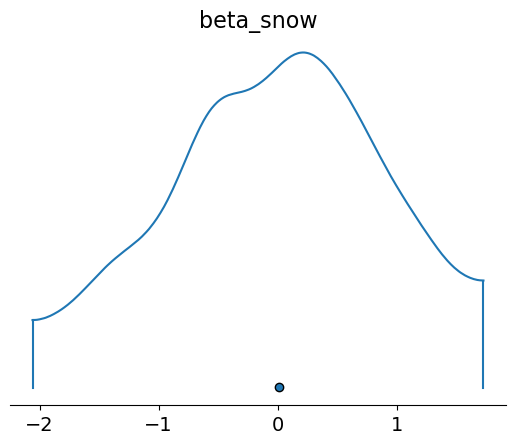

In [19]:
plot_all_prior_coefficients(model_depth_prior)

In [20]:
prior_summary = summarize_all_prior_coefficients(model_depth_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-13.16,1.51,-15.97,-10.24,0.05,0.03,912.74,844.59,NaN
sigma,3.23,2.39,0.01,7.32,0.08,0.06,1023.86,918.86,NaN
beta_snow,0.01,1.01,-2.06,1.73,0.03,0.02,990.58,944.20,NaN


In [21]:
summary = summarize_all_posterior_coefficients(model_depth_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.26,0.24,0.79,1.71,0.00,0.00,3929.44,4825.59,1.0
alpha,-12.32,1.23,-14.64,-10.01,0.02,0.01,3943.81,4862.03,1.0
sigma,2.07,0.60,1.22,3.20,0.01,0.01,4572.69,4907.92,1.0


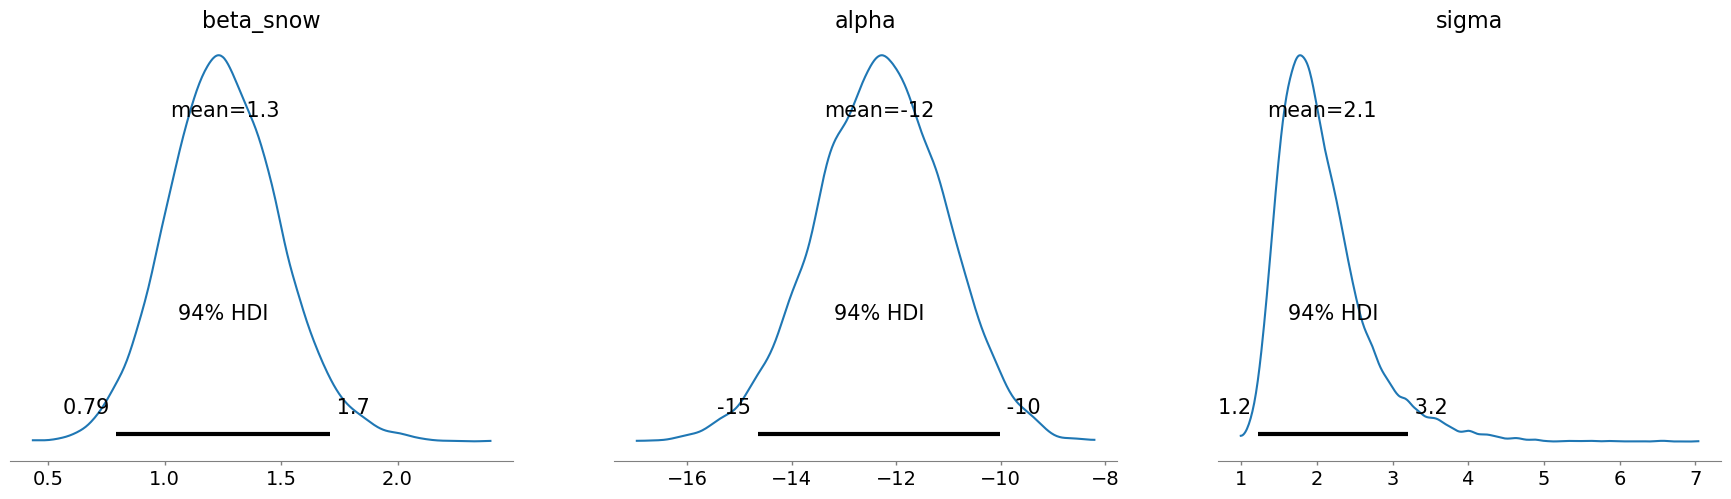

In [22]:
plot_all_posterior_coefficients(model_depth_idata)

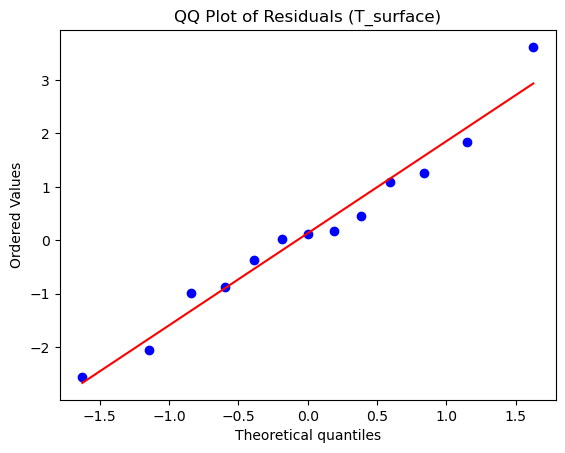

In [23]:
residuals = plot_residual_qq(
    model_depth_idata,
    T_surface,
    var_name="T_surface"
)

In [24]:
r2_table = compute_bayesian_r2(
    model_depth_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.522271,0.108259


In [25]:
loo_depth = compute_loo(model_depth_idata)
print(loo_depth)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -27.70     2.49
p_loo        2.31        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

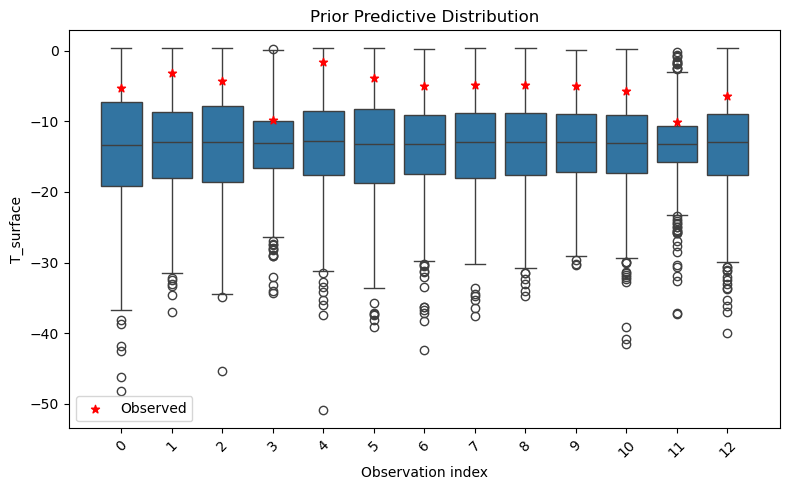

In [26]:
plot_prior_predictions(model_depth_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

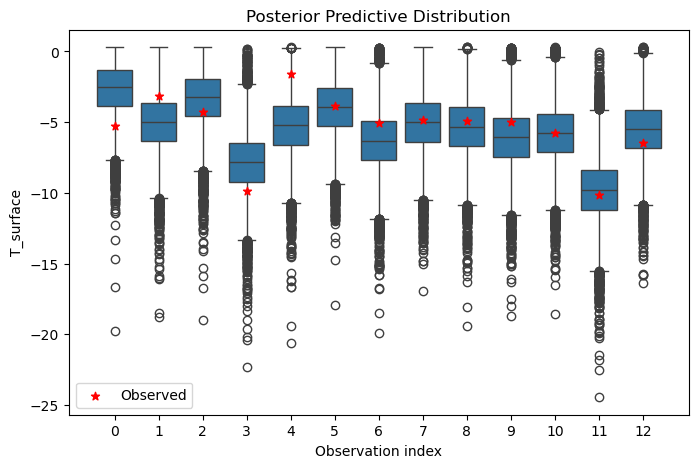

In [27]:
plot_predictions(model_depth_idata)

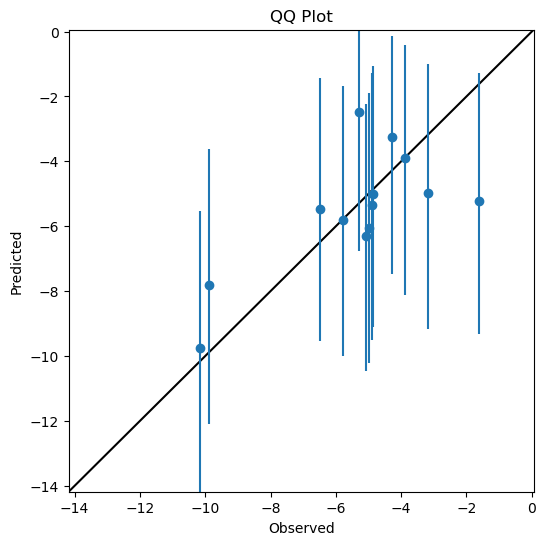

In [28]:
qqplot(model_depth_idata)

## model_topography

In [29]:
T_surface = df["T_surface"].values

with pm.Model() as model_topography:

    # -------------------------
    # Data
    # -------------------------
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,       
        sigma=1.5,     
        upper=0.3       
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,       
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [30]:
model_topography_prior, model_topography_idata = run_model(model_topography)

Sampling: [T_surface, alpha, beta_cos, beta_elev, beta_sin, beta_slope, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 87 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

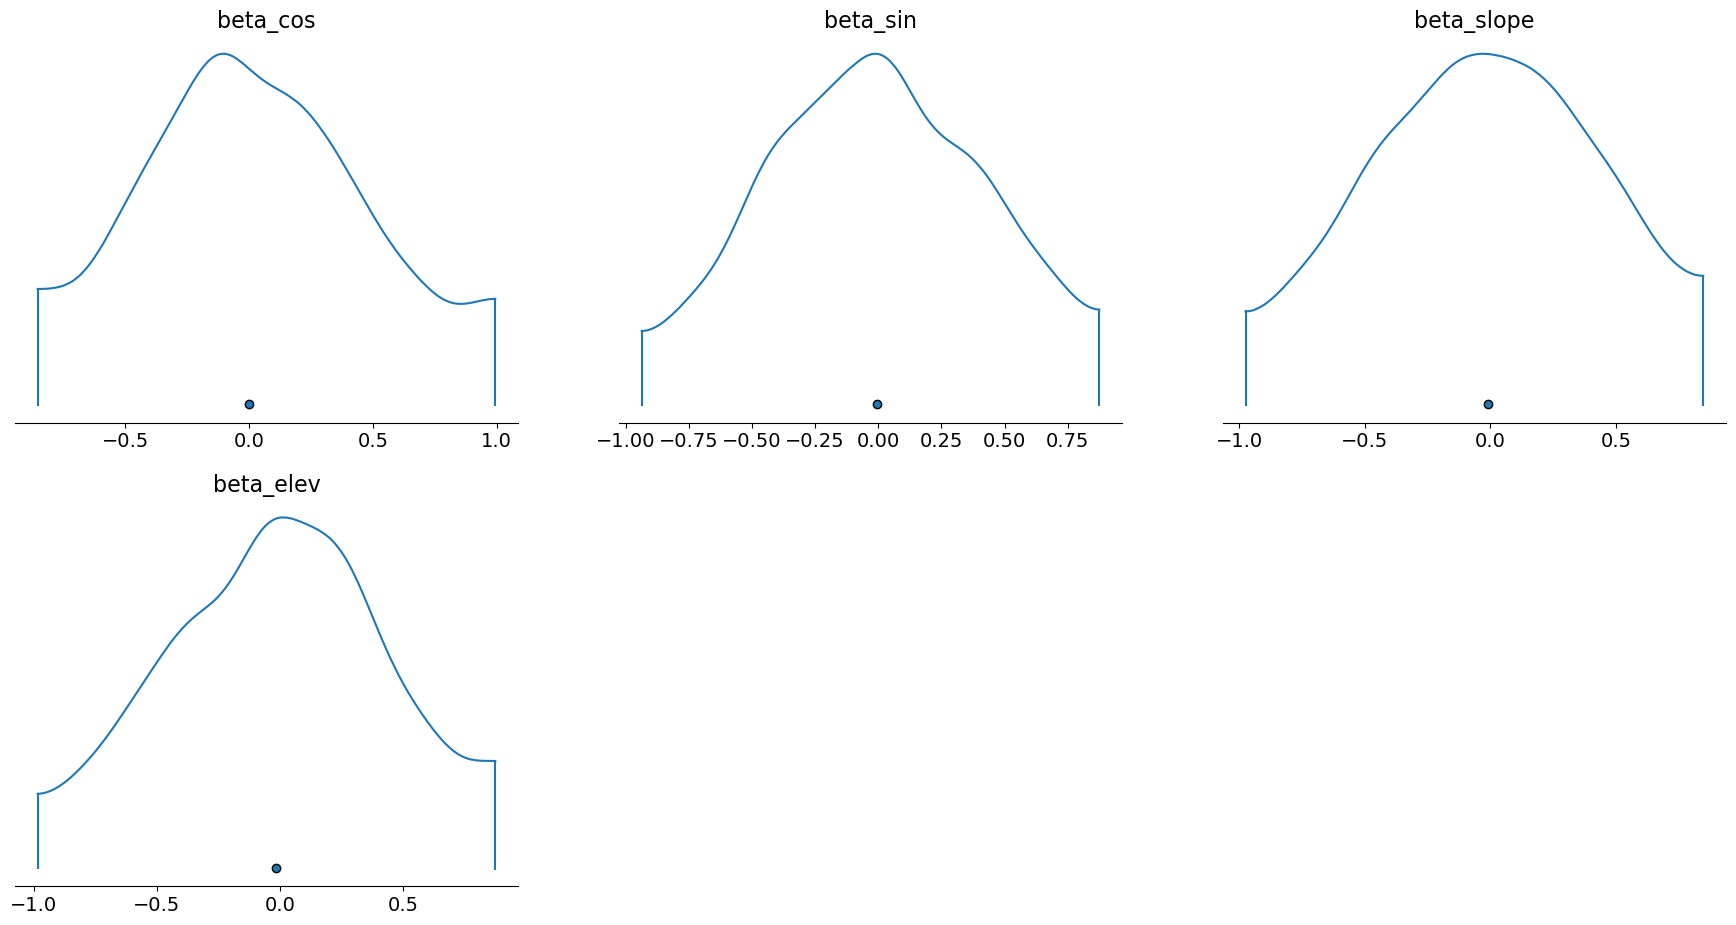

In [31]:
plot_all_prior_coefficients(model_topography_prior)

In [32]:
prior_summary = summarize_all_prior_coefficients(model_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_cos,0.00,0.50,-0.85,1.00,0.02,0.01,918.41,857.43,NaN
sigma,3.24,2.48,0.01,7.64,0.09,0.07,952.05,944.34,NaN
beta_sin,-0.00,0.48,-0.94,0.88,0.02,0.01,878.42,908.23,NaN
alpha,-13.25,1.55,-15.89,-10.31,0.05,0.04,969.87,907.70,NaN
beta_slope,-0.01,0.49,-0.98,0.85,0.02,0.01,983.56,941.46,NaN
beta_elev,-0.02,0.50,-0.99,0.88,0.02,0.01,850.08,948.44,NaN


In [33]:
summary = summarize_all_posterior_coefficients(model_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_slope,0.07,0.24,-0.36,0.55,0.00,0.00,7180.52,5015.79,1.0
beta_elev,0.71,0.21,0.30,1.09,0.00,0.00,6487.93,6991.10,1.0
beta_sin,-0.17,0.49,-1.11,0.70,0.00,0.00,10113.13,8124.53,1.0
beta_cos,0.14,0.48,-0.72,1.06,0.00,0.00,10266.86,7958.17,1.0
alpha,-12.22,1.41,-14.91,-9.58,0.02,0.01,8031.95,6733.57,1.0
sigma,3.47,1.10,1.85,5.57,0.01,0.02,6266.86,7183.16,1.0


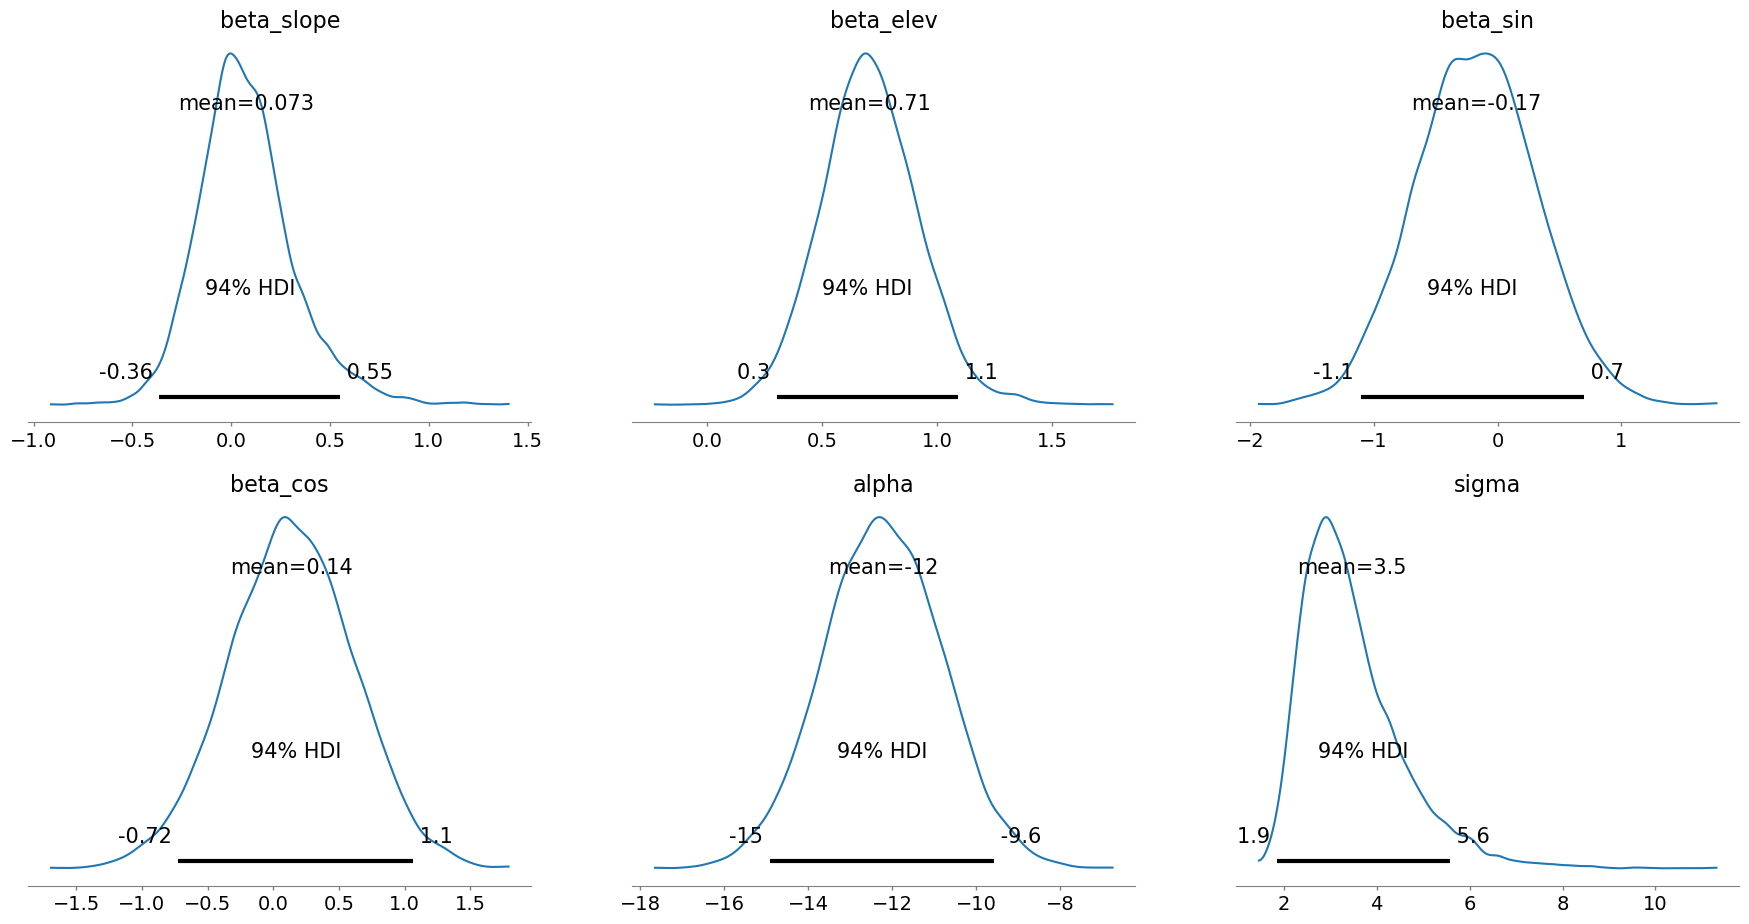

In [34]:
plot_all_posterior_coefficients(model_topography_idata)

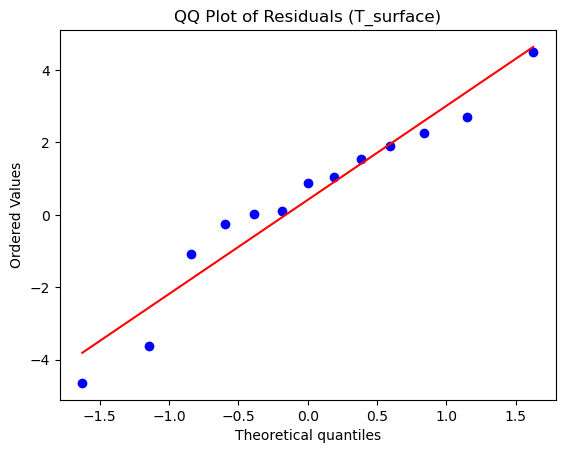

In [35]:
residuals = plot_residual_qq(
    model_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [36]:
r2_table = compute_bayesian_r2(
    model_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.382933,0.085492


In [37]:
loo_topography = compute_loo(model_topography_idata)
print(loo_topography)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -33.07     1.90
p_loo        2.15        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

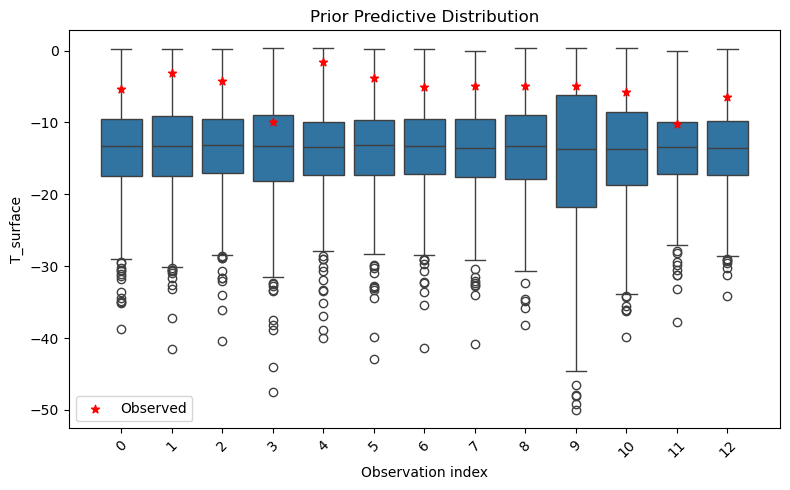

In [38]:
plot_prior_predictions(model_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

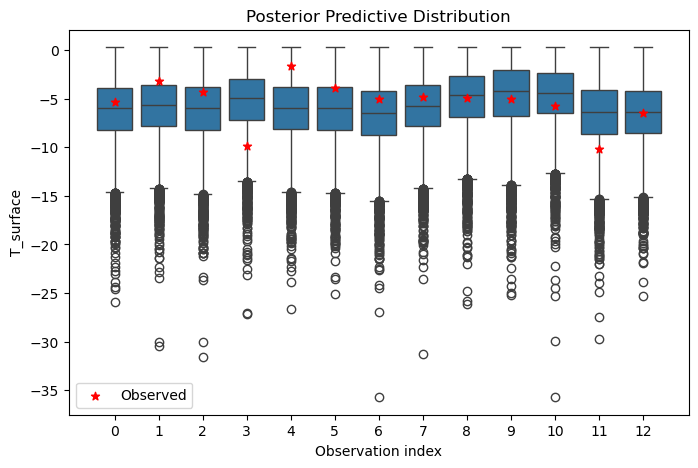

In [39]:
plot_predictions(model_topography_idata)

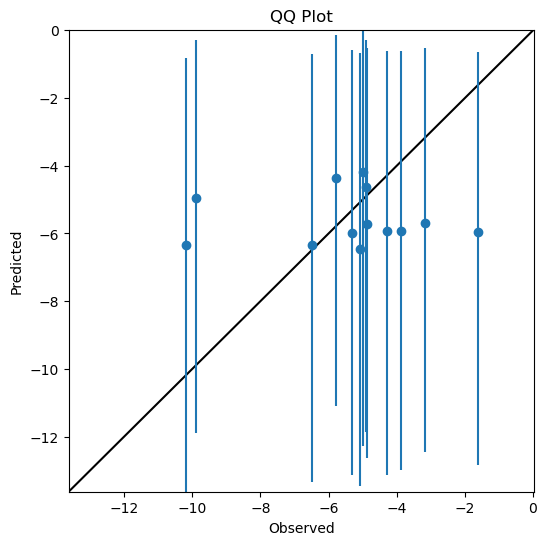

In [40]:
qqplot(model_topography_idata)

## model_density

In [41]:
T_surface = df["T_surface"].values

with pm.Model() as model_density:

    # -------------------------
    # Data
    density = pm.Data("density", df["density_01"].values) 


    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        
        sigma=1.5,      
        upper=0.3       
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_density = pm.Normal(
        "beta_density",
        mu=0,        
        sigma=1
    )


    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_density * density
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [42]:
model_density_prior, model_density_idata = run_model(model_density)

Sampling: [T_surface, alpha, beta_density, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_density, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 130 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

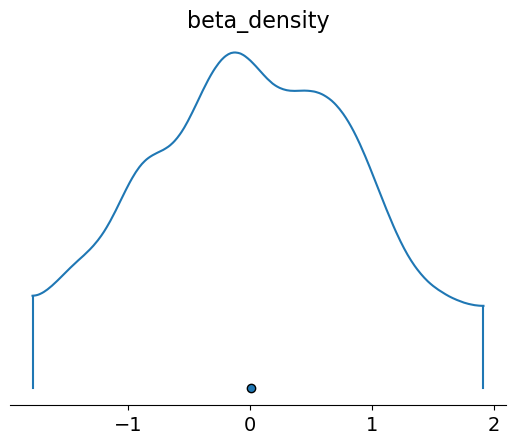

In [43]:
plot_all_prior_coefficients(model_density_prior)

In [44]:
prior_summary = summarize_all_prior_coefficients(model_density_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_density,0.01,1.00,-1.79,1.92,0.03,0.02,932.79,848.39,NaN
alpha,-13.19,1.43,-15.84,-10.58,0.05,0.04,996.70,712.00,NaN
sigma,3.22,2.42,0.02,7.67,0.08,0.06,963.65,981.99,NaN


In [45]:
summary = summarize_all_posterior_coefficients(model_density_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_density,1.98,0.50,1.10,2.99,0.01,0.01,5469.28,6367.32,1.0
alpha,-11.53,1.33,-13.97,-8.99,0.02,0.01,5532.42,5336.04,1.0
sigma,2.94,0.80,1.70,4.32,0.01,0.01,5698.07,5882.93,1.0


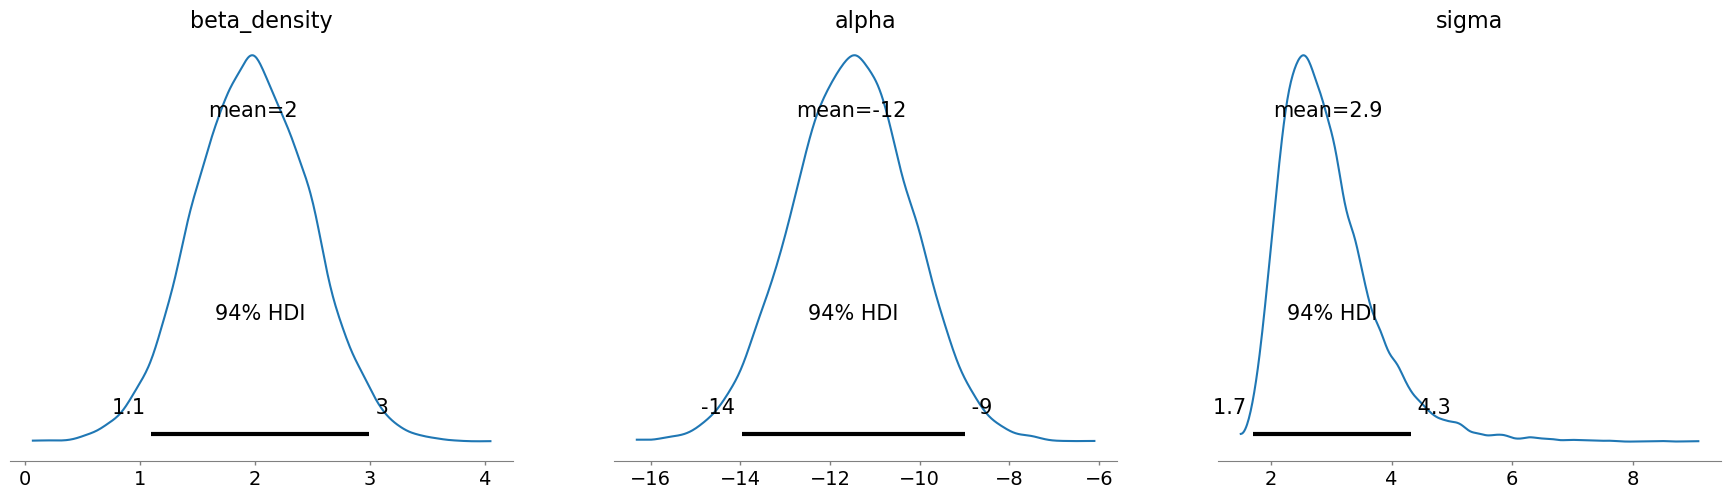

In [46]:
plot_all_posterior_coefficients(model_density_idata)

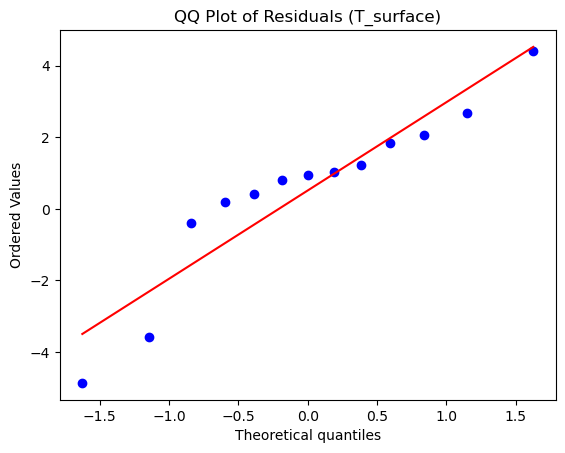

In [47]:
residuals = plot_residual_qq(
    model_density_idata,
    T_surface,
    var_name="T_surface"
)

In [48]:
r2_table = compute_bayesian_r2(
    model_density_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.351997,0.089034


In [49]:
loo_density = compute_loo(model_density_idata)
print(loo_density)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -31.90     2.57
p_loo        1.97        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

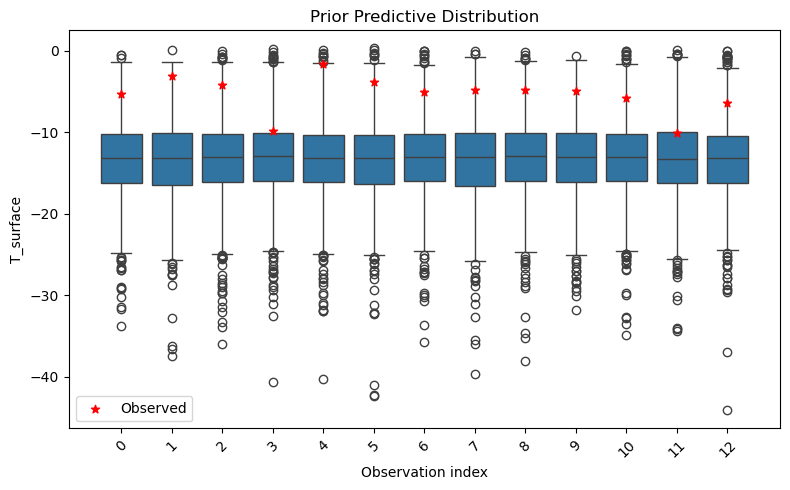

In [50]:
plot_prior_predictions(model_density_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

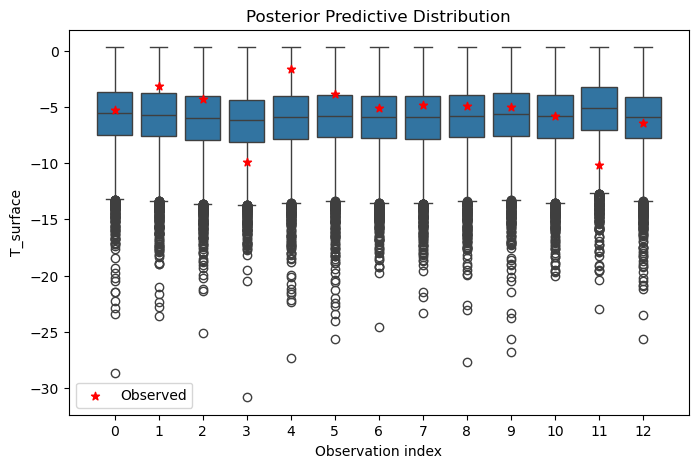

In [51]:
plot_predictions(model_density_idata)

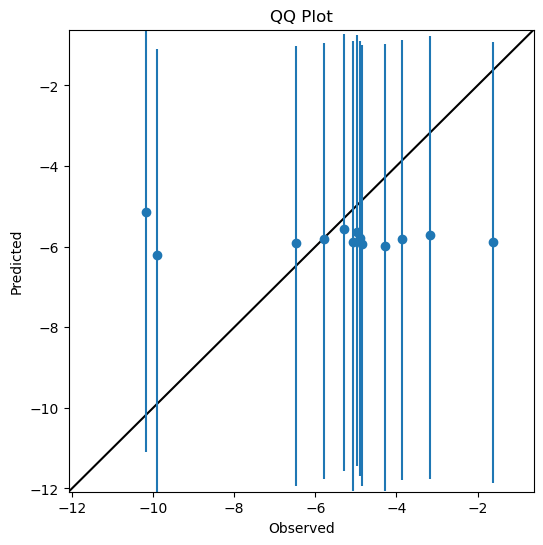

In [52]:
qqplot(model_density_idata)

## model_depth_density

In [53]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_density:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)       
    density = pm.Data("density", df["density_01"].values) 
   
    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        
        sigma=1.5,      
        upper=0.3       
    )
    
    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,         
        sigma=1
    )

    beta_density = pm.Normal(
        "beta_density",
        mu=0,         
        sigma=1
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_density * density
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [54]:
model_depth_density_prior, model_depth_density_idata = run_model(model_depth_density)

Sampling: [T_surface, alpha, beta_density, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma, beta_snow, beta_density]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 98 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

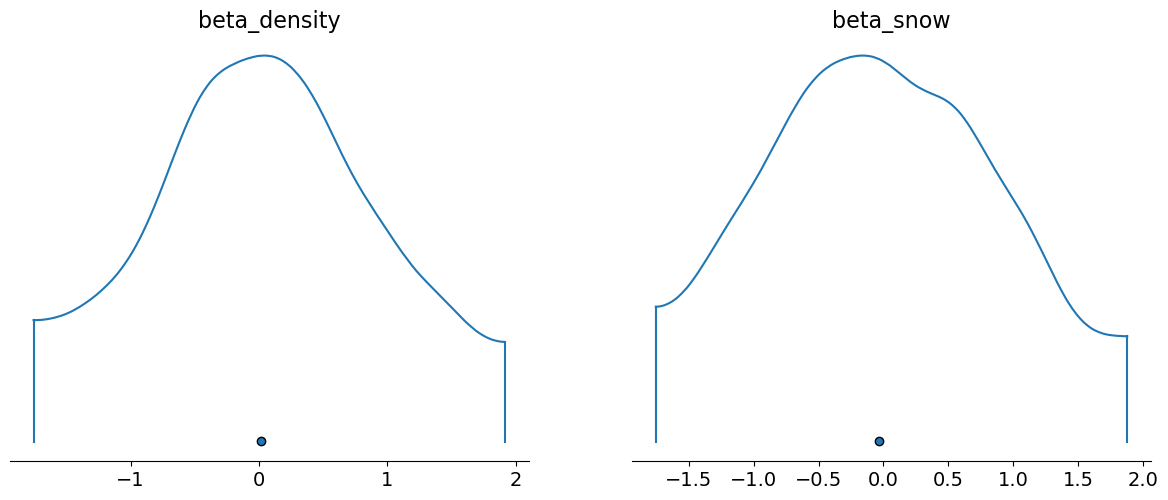

In [55]:
plot_all_prior_coefficients(model_depth_density_prior)

In [56]:
prior_summary = summarize_all_prior_coefficients(model_depth_density_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.32,2.47,0.00,7.87,0.08,0.06,873.73,907.04,NaN
beta_density,0.01,0.98,-1.76,1.92,0.03,0.02,833.05,872.31,NaN
alpha,-13.27,1.47,-15.82,-10.32,0.05,0.03,984.88,820.77,NaN
beta_snow,-0.03,1.00,-1.76,1.88,0.03,0.02,941.14,976.84,NaN


In [57]:
summary = summarize_all_posterior_coefficients(model_depth_density_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.12,0.31,0.50,1.69,0.00,0.00,5749.68,5461.58,1.0
beta_density,0.45,0.63,-0.74,1.62,0.01,0.01,5098.08,5895.10,1.0
alpha,-12.82,1.39,-15.46,-10.24,0.02,0.01,6848.36,6088.53,1.0
sigma,2.09,0.60,1.21,3.19,0.01,0.01,5914.33,4889.63,1.0


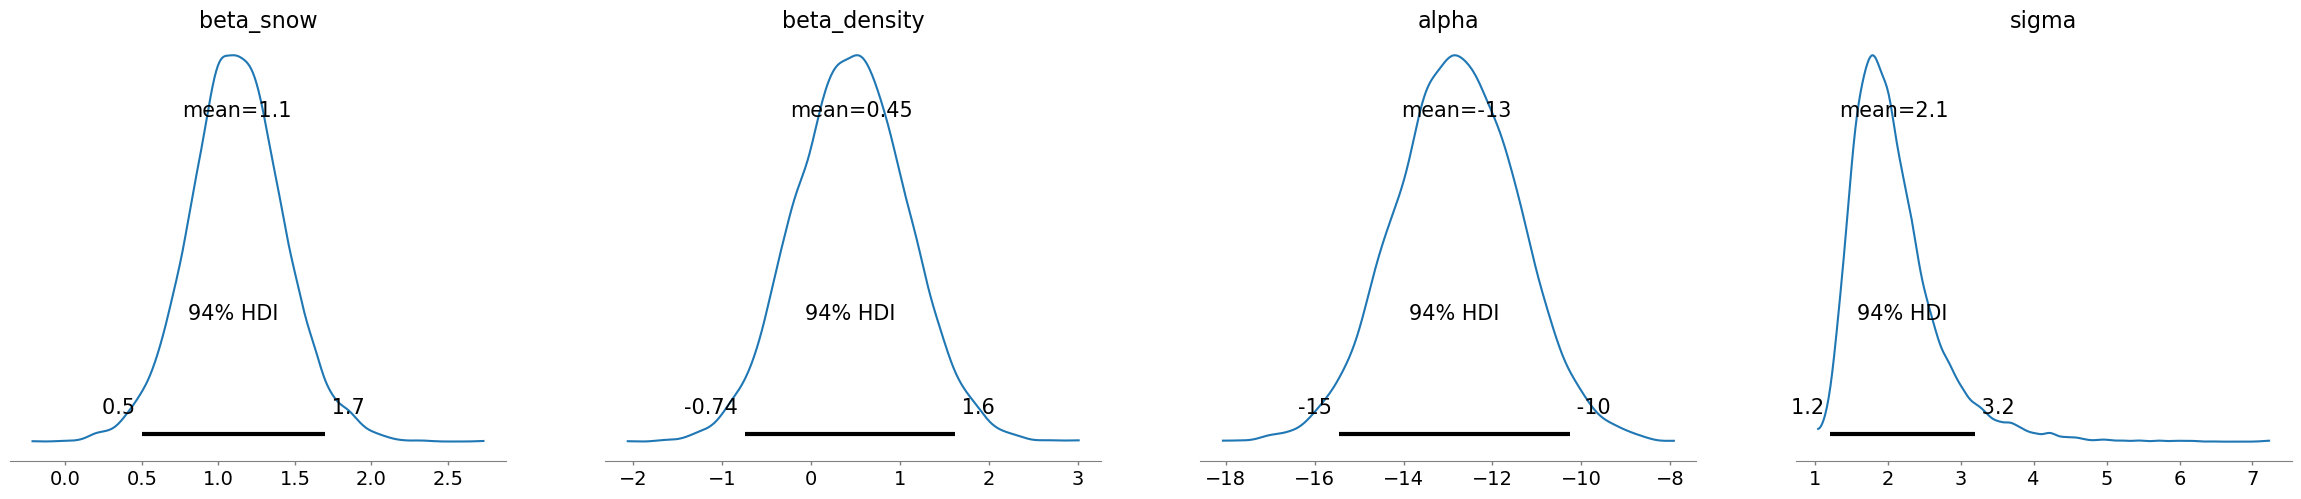

In [58]:
plot_all_posterior_coefficients(model_depth_density_idata)

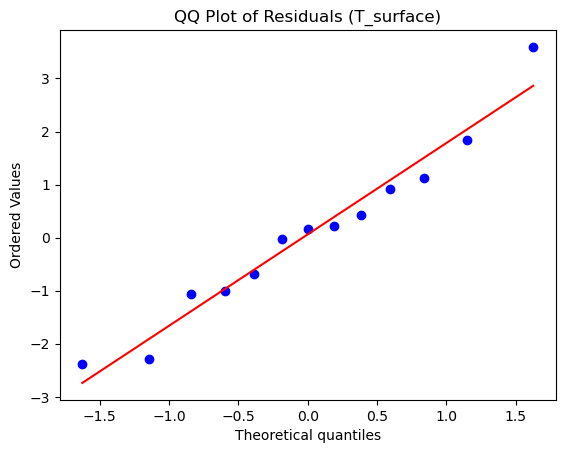

In [59]:
residuals = plot_residual_qq(
    model_depth_density_idata,
    T_surface,
    var_name="T_surface"
)

In [60]:
r2_table = compute_bayesian_r2(
    model_depth_density_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.493773,0.118142


In [61]:
loo_depth_density = compute_loo(model_depth_density_idata)
print(loo_depth_density)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -27.97     2.38
p_loo        2.51        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

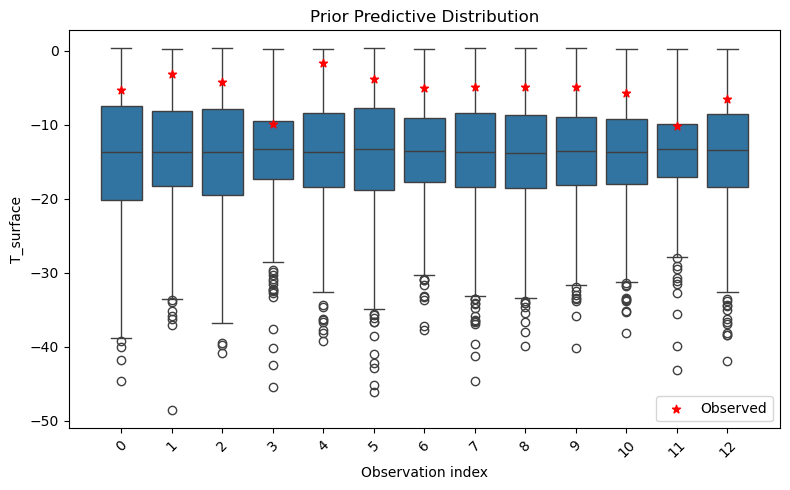

In [62]:
plot_prior_predictions(model_depth_density_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

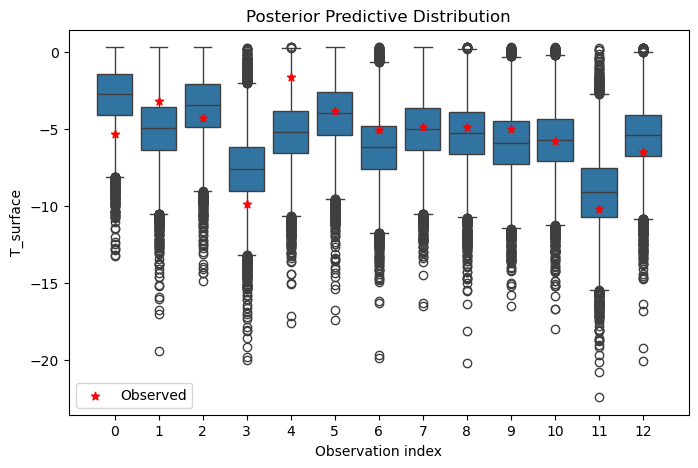

In [63]:
plot_predictions(model_depth_density_idata)

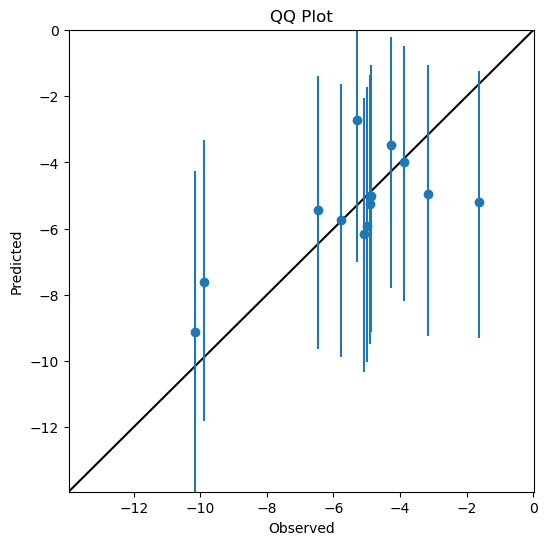

In [64]:
qqplot(model_depth_density_idata)

## model_depth_topography

In [65]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_topography:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)      
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        
        sigma=1.5,      
        upper=0.3       
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,         
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4  
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [66]:
model_depth_topography_prior, model_depth_topography_idata = run_model(model_depth_topography)

Sampling: [T_surface, alpha, beta_cos, beta_elev, beta_sin, beta_slope, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 100 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

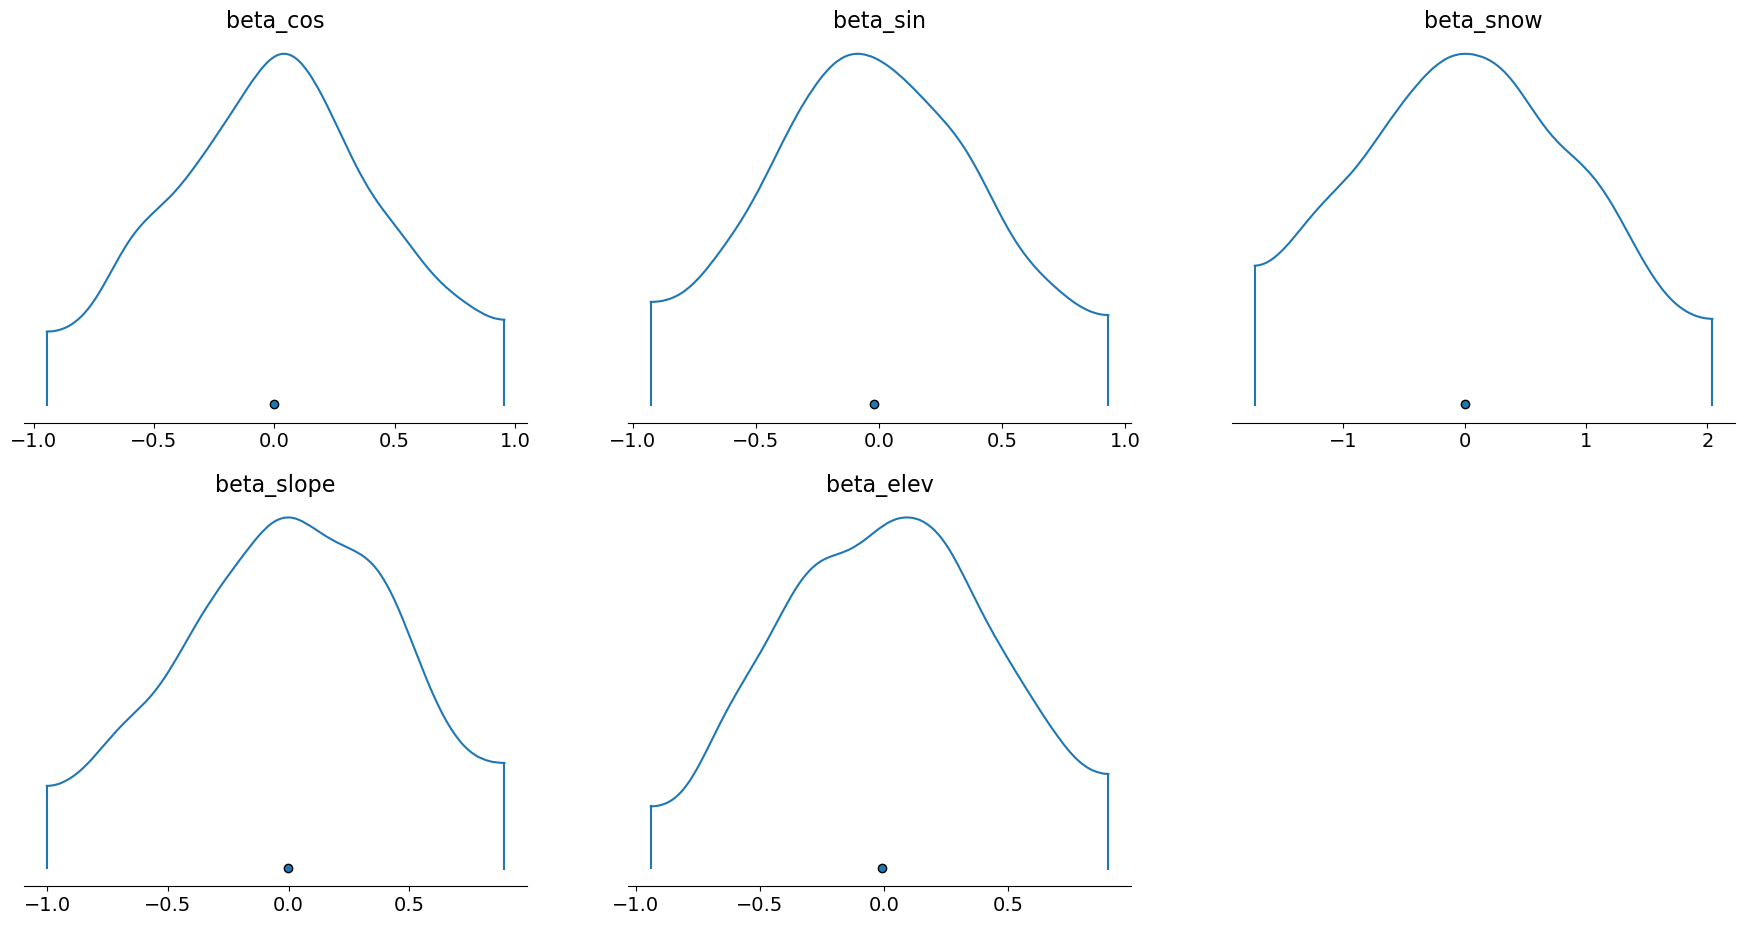

In [67]:
plot_all_prior_coefficients(model_depth_topography_prior)

In [68]:
prior_summary = summarize_all_prior_coefficients(model_depth_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_cos,0.00,0.50,-0.95,0.96,0.02,0.01,935.93,991.76,NaN
sigma,3.29,2.46,0.01,7.79,0.08,0.08,978.78,972.12,NaN
beta_sin,-0.02,0.50,-0.93,0.93,0.02,0.01,991.86,883.34,NaN
alpha,-13.26,1.54,-15.94,-10.18,0.05,0.04,987.19,907.70,NaN
beta_snow,0.00,1.04,-1.73,2.04,0.03,0.02,1036.15,778.44,NaN
beta_slope,-0.00,0.50,-1.00,0.90,0.02,0.01,874.11,899.34,NaN
beta_elev,-0.01,0.49,-0.94,0.91,0.02,0.01,985.81,907.04,NaN


In [69]:
summary = summarize_all_posterior_coefficients(model_depth_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.12,0.37,0.43,1.82,0.00,0.00,6645.02,6188.02,1.0
beta_slope,0.07,0.16,-0.20,0.38,0.00,0.00,7626.04,5026.27,1.0
beta_elev,0.11,0.25,-0.36,0.59,0.00,0.00,6026.52,6826.17,1.0
beta_sin,-0.15,0.46,-1.04,0.68,0.00,0.00,9395.04,8282.80,1.0
beta_cos,0.11,0.45,-0.71,0.97,0.00,0.00,9579.52,8121.21,1.0
alpha,-12.78,1.41,-15.40,-10.11,0.02,0.01,7634.43,6750.73,1.0
sigma,2.32,0.81,1.20,3.82,0.01,0.02,4642.47,4177.54,1.0


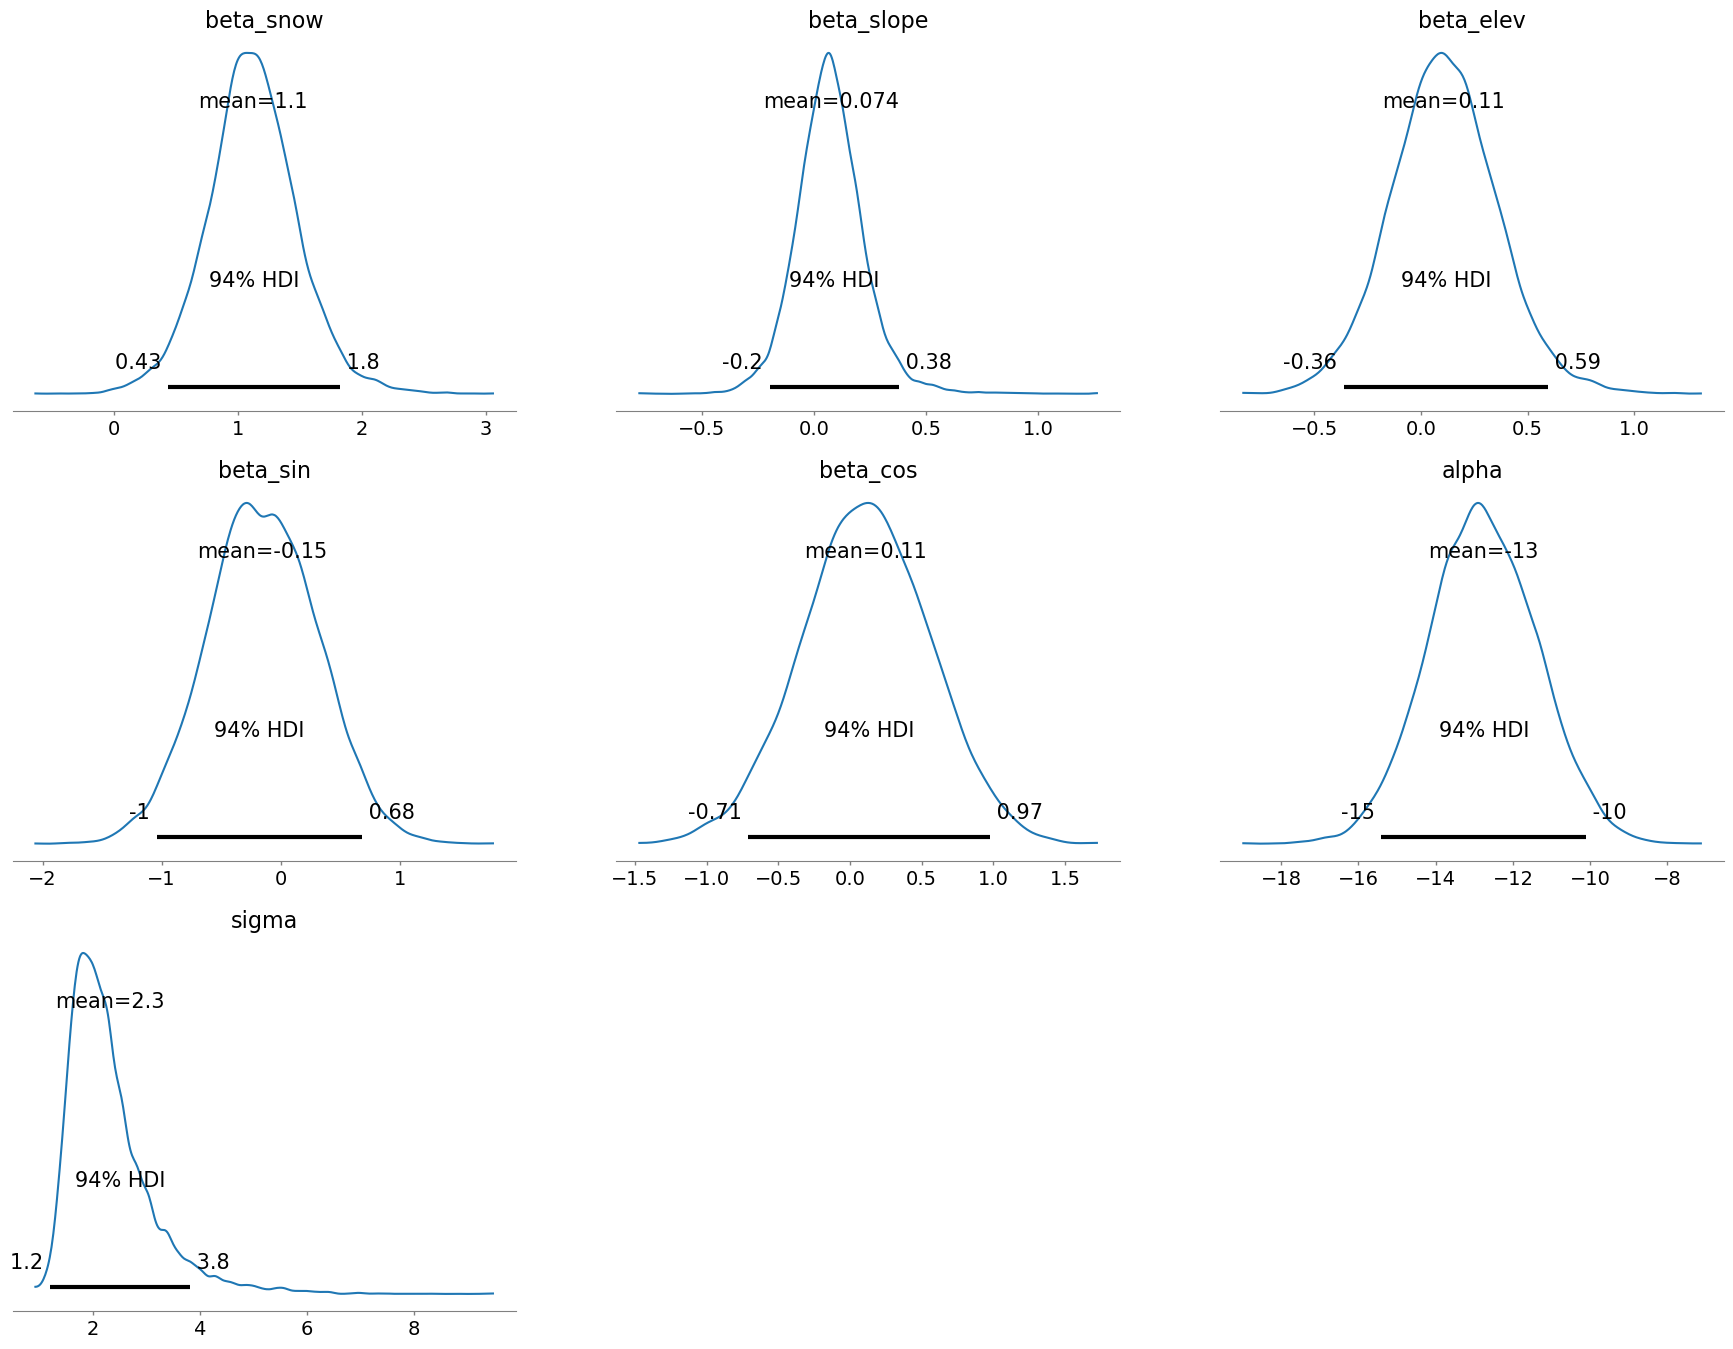

In [70]:
plot_all_posterior_coefficients(model_depth_topography_idata)

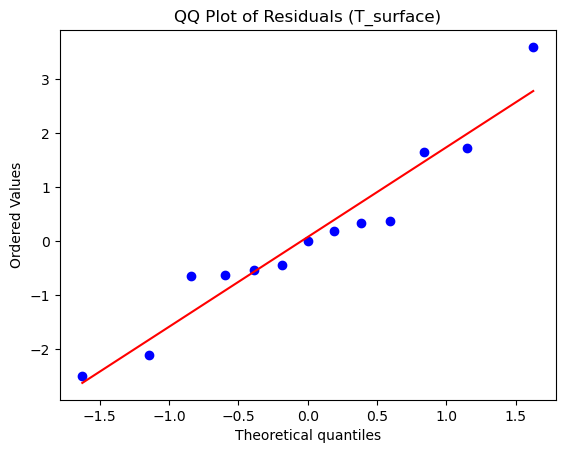

In [71]:
residuals = plot_residual_qq(
    model_depth_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [72]:
r2_table = compute_bayesian_r2(
    model_depth_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.504786,0.112039


In [73]:
loo_depth_topography = compute_loo(model_depth_topography_idata)
print(loo_depth_topography)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -29.75     2.35
p_loo        3.68        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       12   92.3%
   (0.70, 1]   (bad)         1    7.7%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

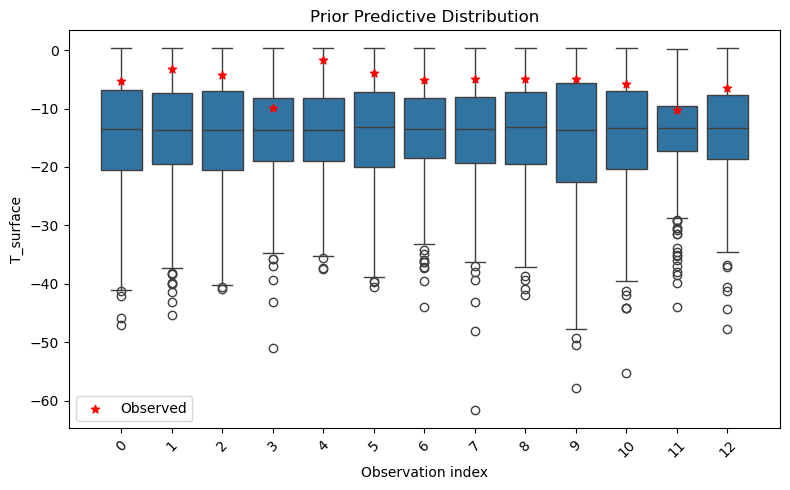

In [74]:
plot_prior_predictions(model_depth_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

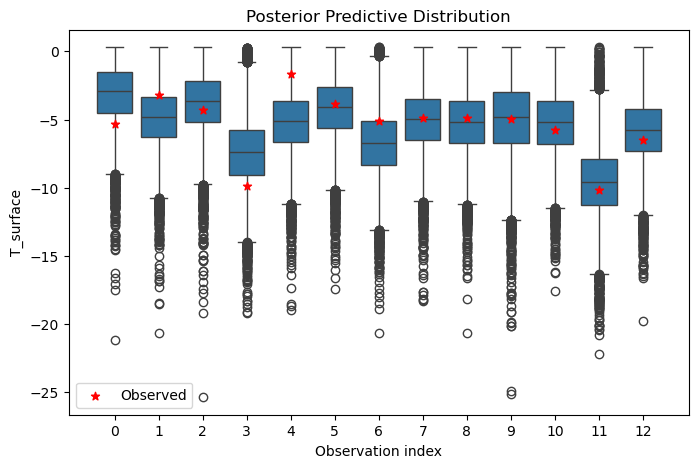

In [75]:
plot_predictions(model_depth_topography_idata)

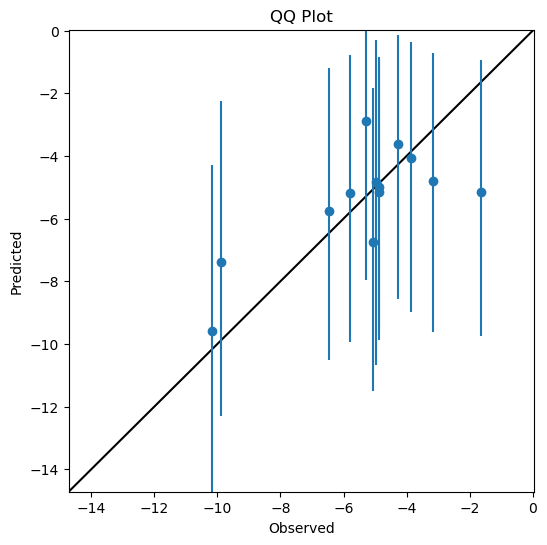

In [76]:
qqplot(model_depth_topography_idata)

## model_density_topography

In [77]:
T_surface = df["T_surface"].values

with pm.Model() as model_density_topography:

    # -------------------------
    # Data
    # -------------------------
    density = pm.Data("density", df["density_01"].values) 
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        
        sigma=1.5,      
        upper=0.3       
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_density = pm.Normal(
        "beta_density",
        mu=0,        
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_density * density
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [78]:
model_density_topography_prior, model_density_topography_idata = run_model(model_density_topography)

Sampling: [T_surface, alpha, beta_cos, beta_density, beta_elev, beta_sin, beta_slope, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_density, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 87 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

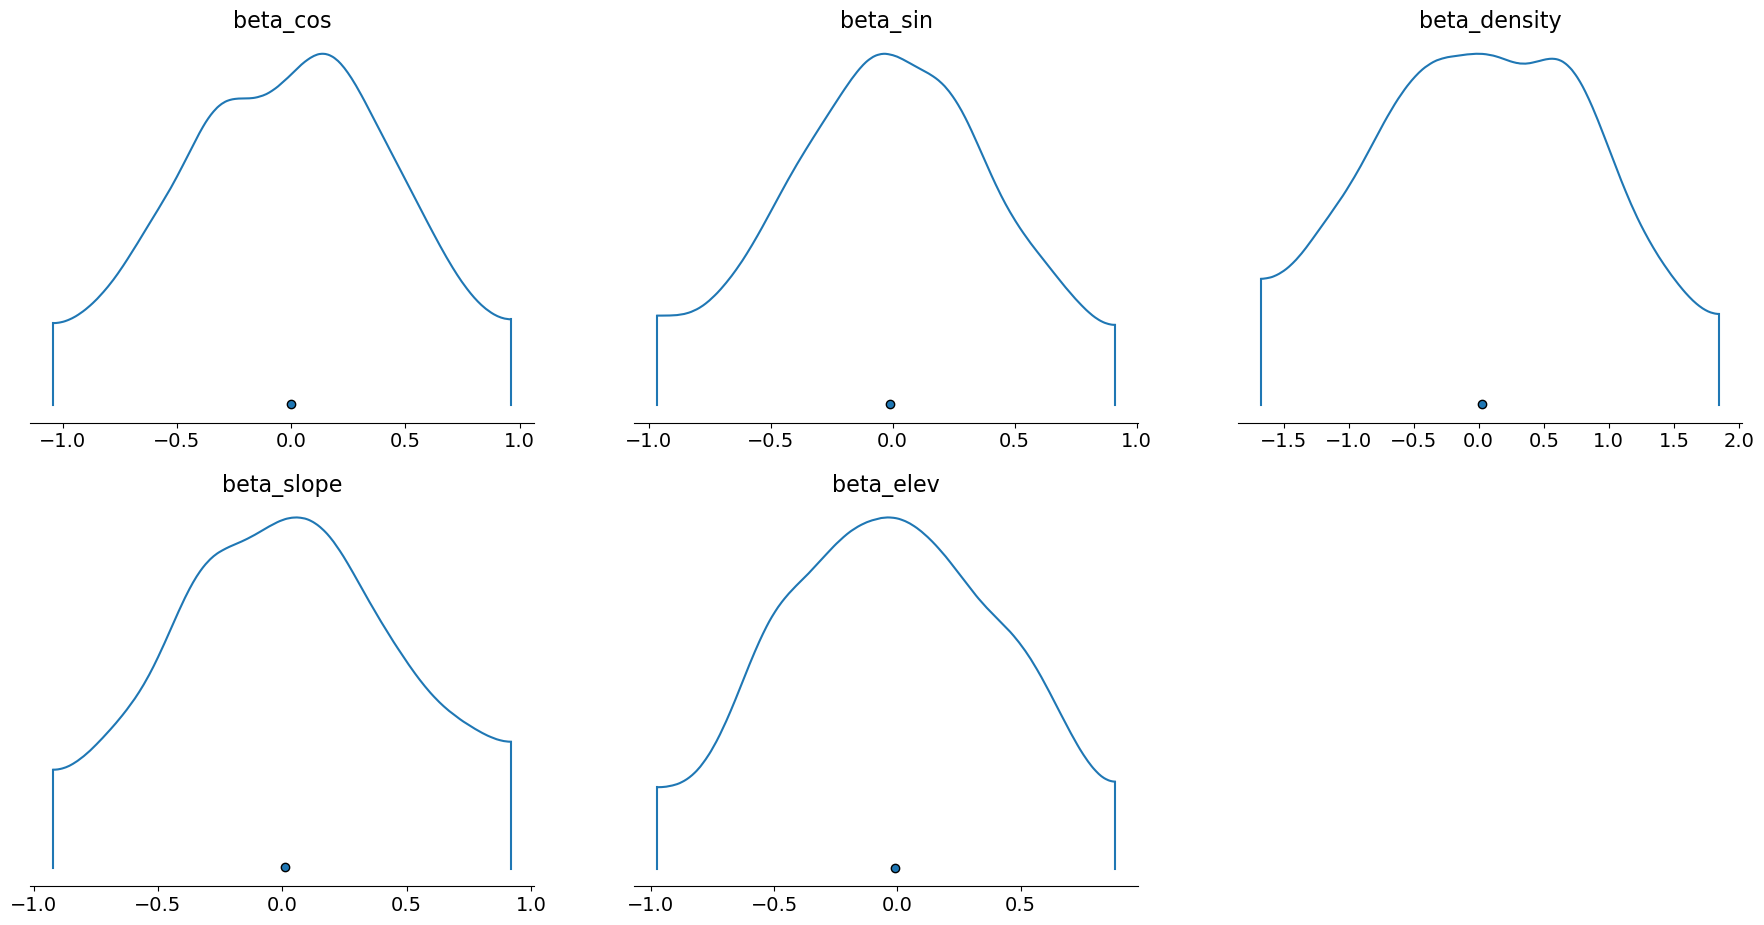

In [79]:
plot_all_prior_coefficients(model_density_topography_prior)

In [80]:
prior_summary = summarize_all_prior_coefficients(model_density_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_cos,0.00,0.53,-1.04,0.96,0.02,0.01,970.73,1055.57,NaN
sigma,3.20,2.41,0.00,7.64,0.08,0.06,854.59,1060.16,NaN
beta_sin,-0.01,0.50,-0.97,0.91,0.02,0.01,918.88,905.50,NaN
beta_density,0.03,0.96,-1.68,1.85,0.03,0.02,891.08,983.28,NaN
alpha,-13.25,1.55,-16.18,-10.59,0.05,0.04,876.01,806.86,NaN
beta_slope,0.01,0.50,-0.92,0.92,0.02,0.01,946.60,1021.22,NaN
beta_elev,-0.01,0.50,-0.98,0.88,0.02,0.01,996.50,874.78,NaN


In [81]:
summary = summarize_all_posterior_coefficients(model_density_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_density,0.85,0.84,-0.71,2.43,0.01,0.01,8790.98,8592.88,1.0
beta_slope,0.07,0.23,-0.37,0.51,0.00,0.00,8491.69,5870.31,1.0
beta_elev,0.48,0.30,-0.09,1.06,0.00,0.00,7147.03,8093.83,1.0
beta_sin,-0.18,0.48,-1.07,0.74,0.00,0.00,10538.49,7985.65,1.0
beta_cos,0.11,0.48,-0.79,1.01,0.00,0.00,10941.98,7869.78,1.0
alpha,-12.44,1.43,-15.16,-9.76,0.01,0.01,10219.24,7042.94,1.0
sigma,3.40,1.07,1.82,5.45,0.01,0.01,6184.04,7377.99,1.0


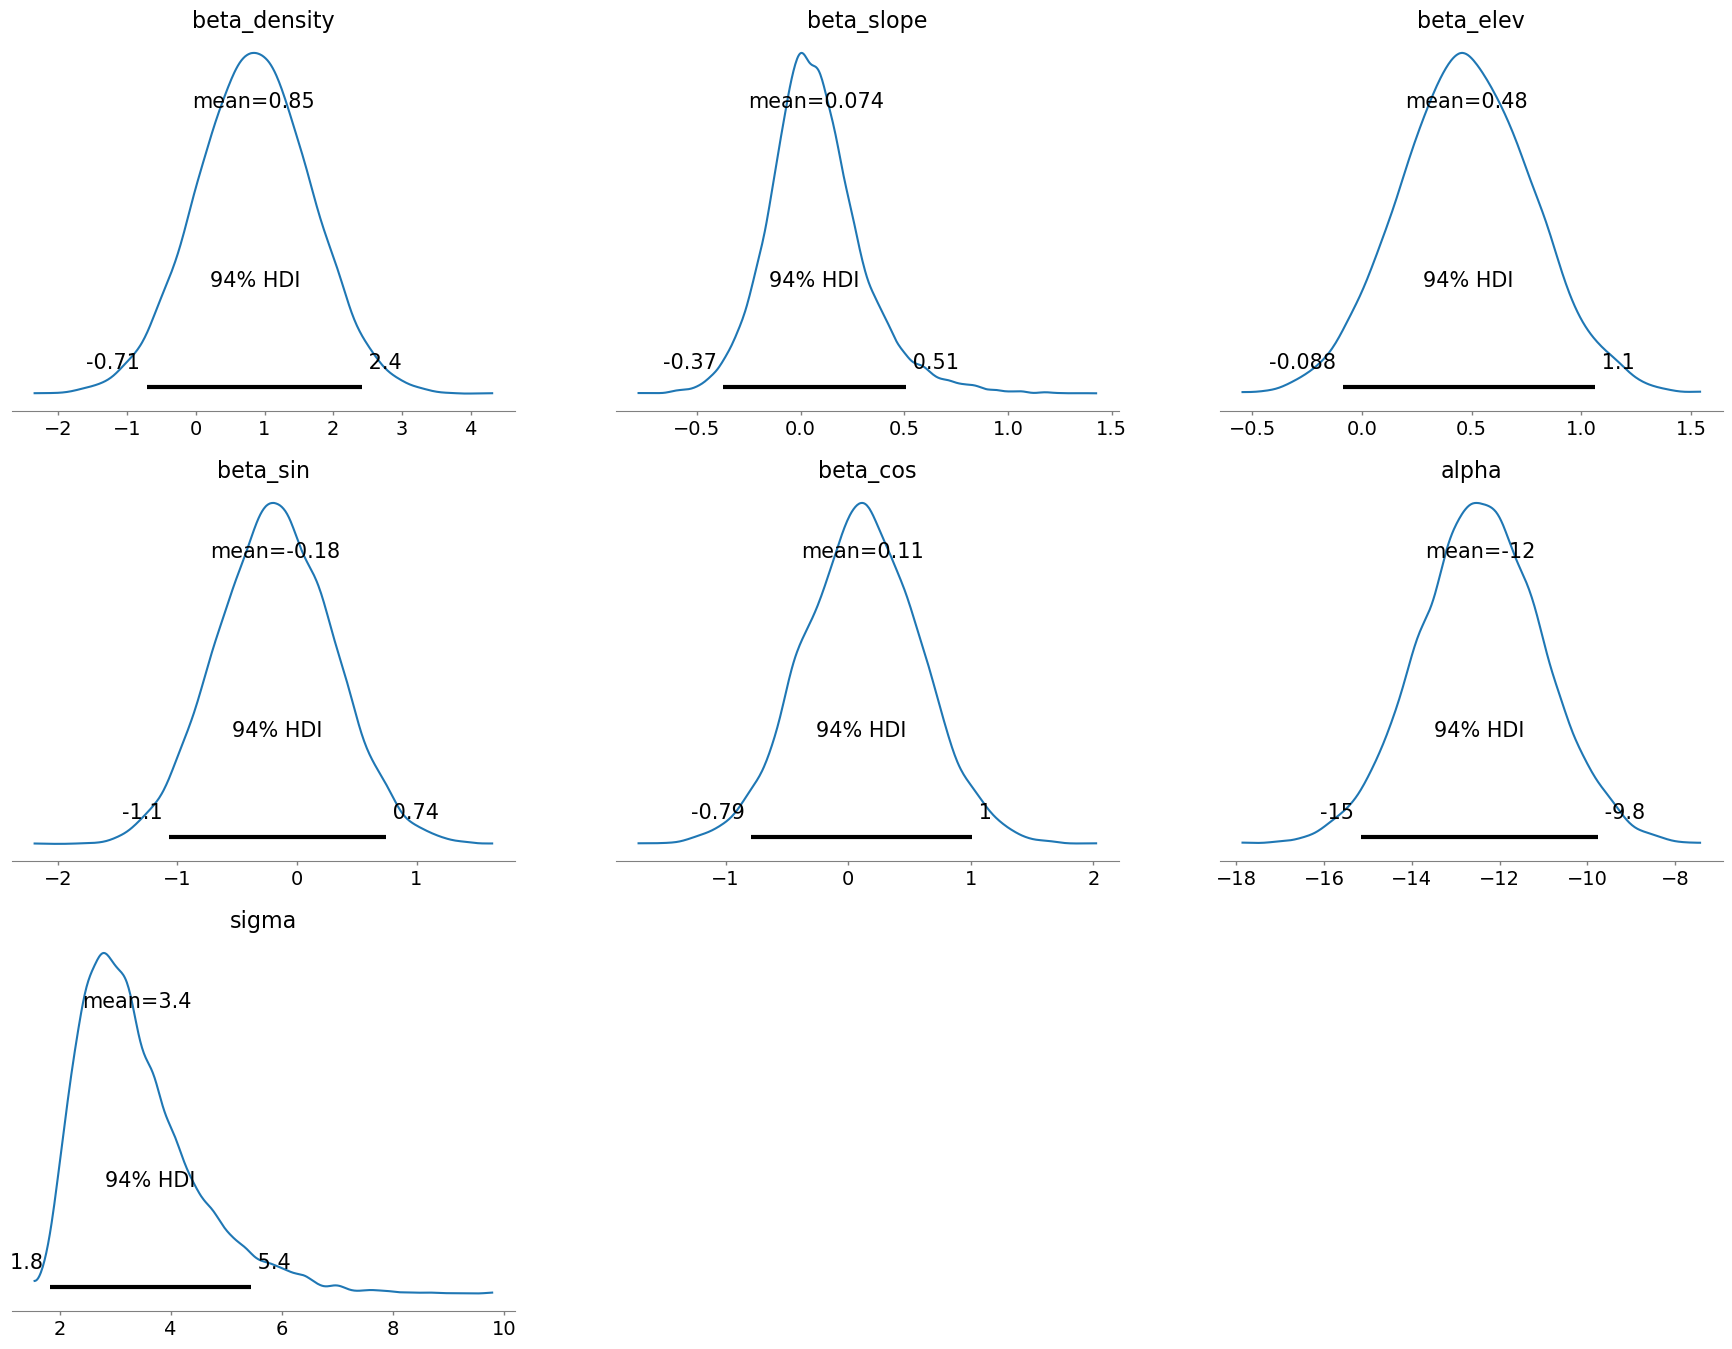

In [82]:
plot_all_posterior_coefficients(model_density_topography_idata)

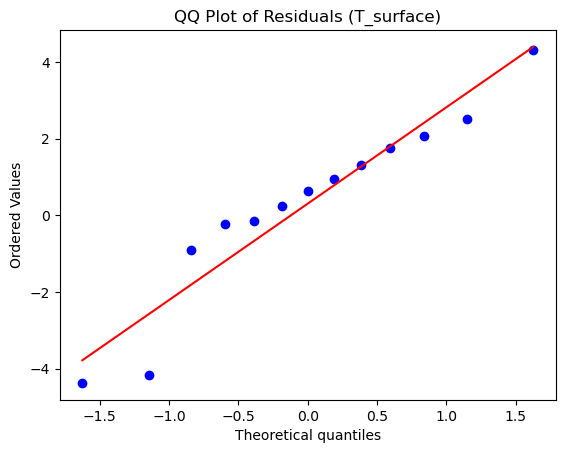

In [83]:
residuals = plot_residual_qq(
    model_density_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [84]:
r2_table = compute_bayesian_r2(
    model_density_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.378457,0.086938


In [85]:
loo_density_topography = compute_loo(model_density_topography_idata)
print(loo_density_topography)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -32.92     2.03
p_loo        2.32        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

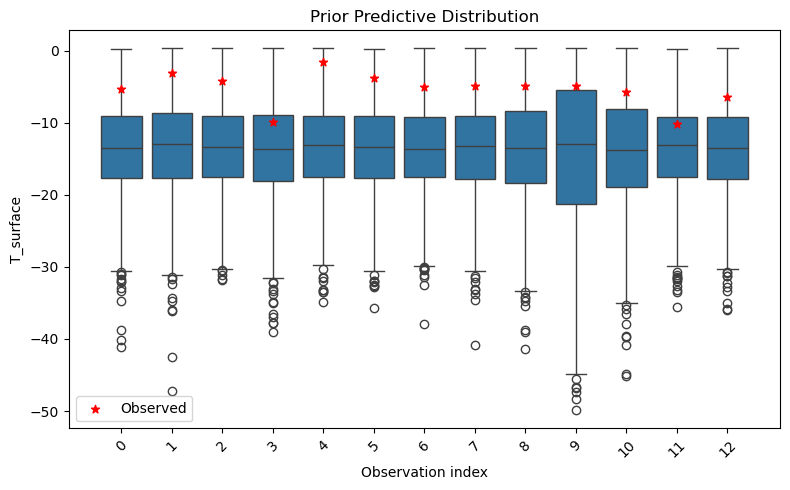

In [86]:
plot_prior_predictions(model_density_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

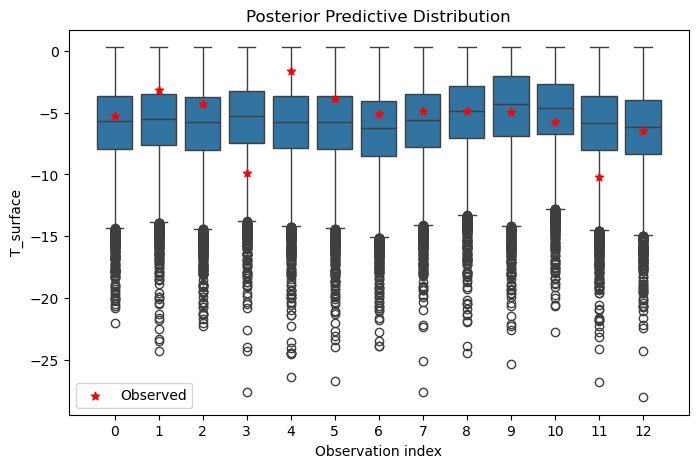

In [87]:
plot_predictions(model_density_topography_idata)

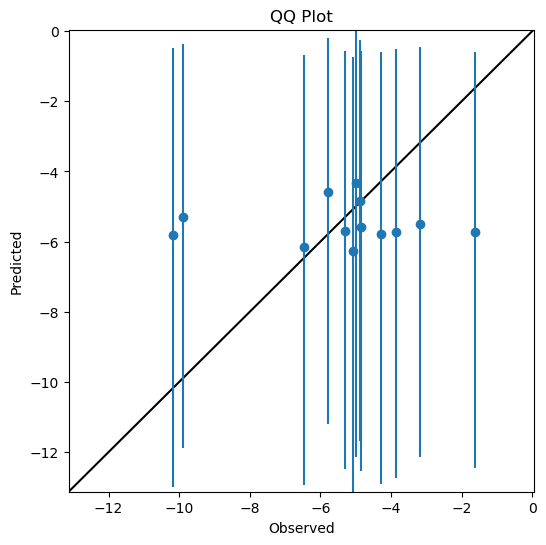

In [88]:
qqplot(model_density_topography_idata)

## model_depth_density_topography

In [89]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_density_topography:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)      
    density = pm.Data("density", df["density_01"].values) 
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        
        sigma=1.5,      
        upper=0.3       
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,        
        sigma=1
    )

    beta_density = pm.Normal(
        "beta_density",
        mu=0,         
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_density * density
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [90]:
model_depth_density_topography_prior, model_depth_density_topography_idata = run_model(model_depth_density_topography)

Sampling: [T_surface, alpha, beta_cos, beta_density, beta_elev, beta_sin, beta_slope, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, beta_density, beta_slope, beta_elev, beta_sin, beta_cos, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 100 seconds.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

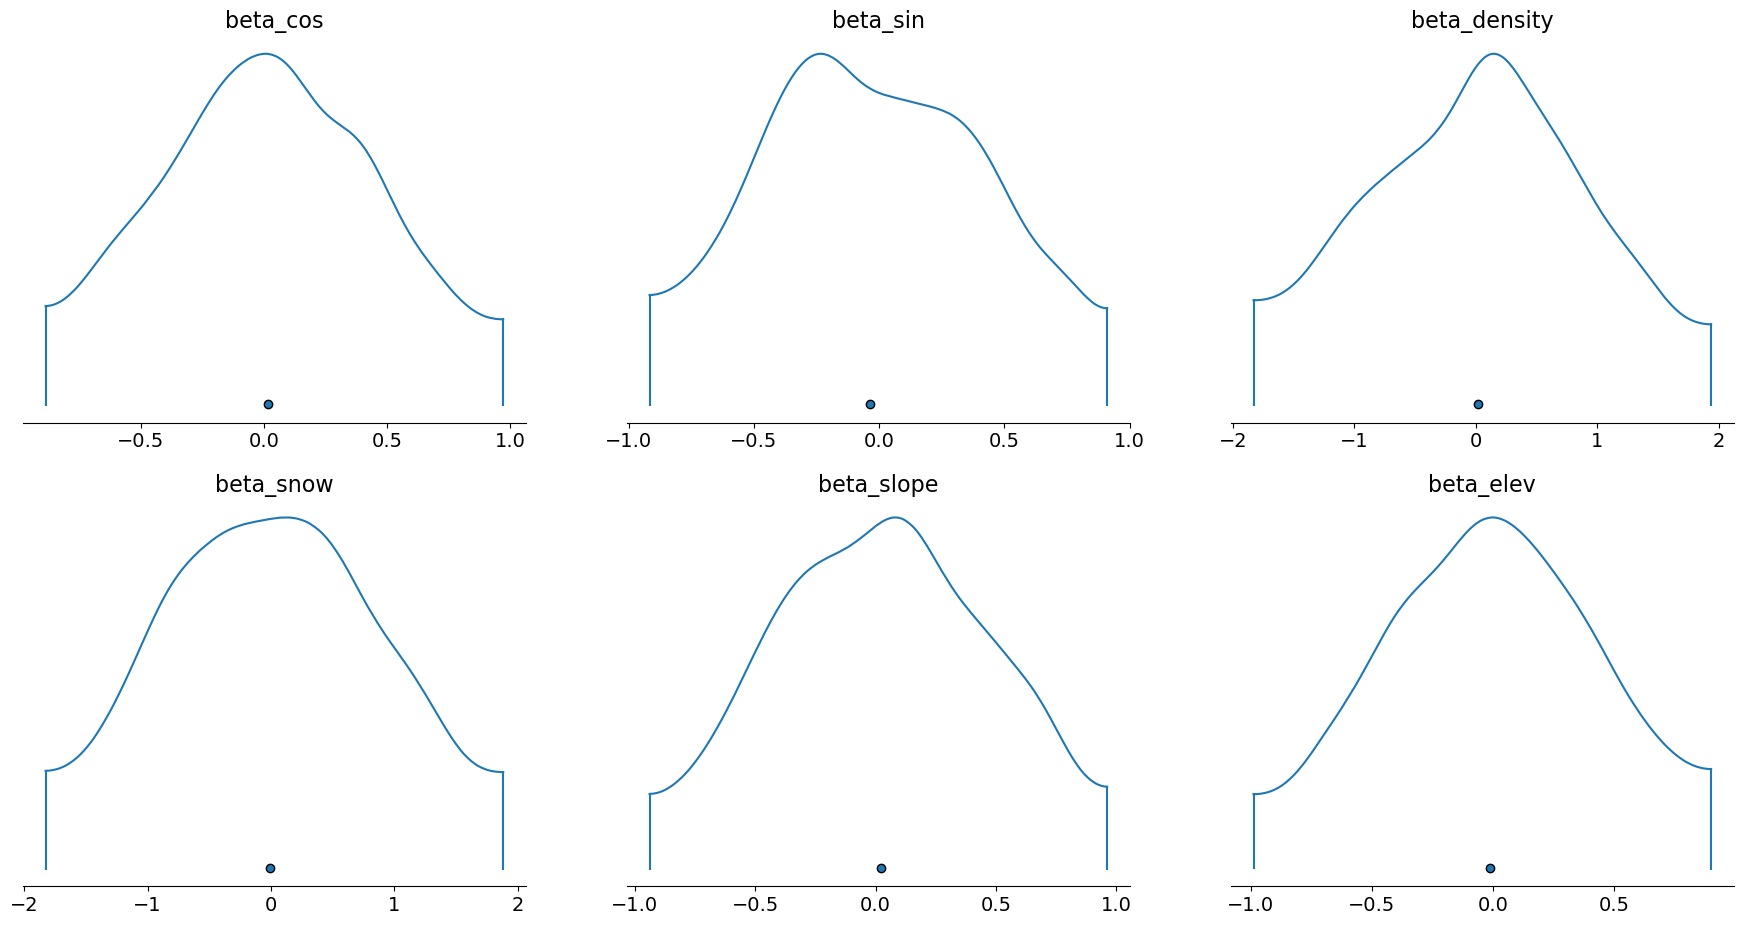

In [91]:
plot_all_prior_coefficients(model_depth_density_topography_prior)

In [92]:
prior_summary = summarize_all_prior_coefficients(model_depth_density_topography_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_cos,0.02,0.50,-0.89,0.97,0.02,0.01,992.58,982.80,NaN
sigma,3.12,2.33,0.00,7.26,0.07,0.07,970.63,907.70,NaN
beta_sin,-0.04,0.51,-0.92,0.91,0.02,0.01,952.10,779.73,NaN
beta_density,0.02,1.02,-1.83,1.94,0.03,0.02,997.91,979.73,NaN
alpha,-13.26,1.49,-16.15,-10.64,0.05,0.04,1039.62,906.13,NaN
beta_snow,-0.01,1.00,-1.83,1.89,0.03,0.02,943.64,811.54,NaN
beta_slope,0.02,0.50,-0.94,0.96,0.02,0.01,812.20,1025.75,NaN
beta_elev,-0.01,0.50,-0.99,0.90,0.02,0.01,945.01,1025.93,NaN


In [93]:
summary = summarize_all_posterior_coefficients(model_depth_density_topography_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.08,0.38,0.40,1.82,0.00,0.00,9053.32,7309.03,1.0
beta_density,0.32,0.83,-1.20,1.92,0.01,0.01,9244.83,7792.94,1.0
beta_slope,0.07,0.16,-0.22,0.37,0.00,0.00,8067.41,5738.27,1.0
beta_elev,0.05,0.31,-0.53,0.63,0.00,0.00,7905.05,7571.24,1.0
beta_sin,-0.16,0.47,-1.00,0.75,0.00,0.00,13176.60,8524.16,1.0
beta_cos,0.09,0.44,-0.77,0.91,0.00,0.00,13386.66,8237.55,1.0
alpha,-12.92,1.44,-15.60,-10.19,0.01,0.01,11358.00,6975.90,1.0
sigma,2.34,0.82,1.24,3.90,0.01,0.02,5617.54,5592.30,1.0


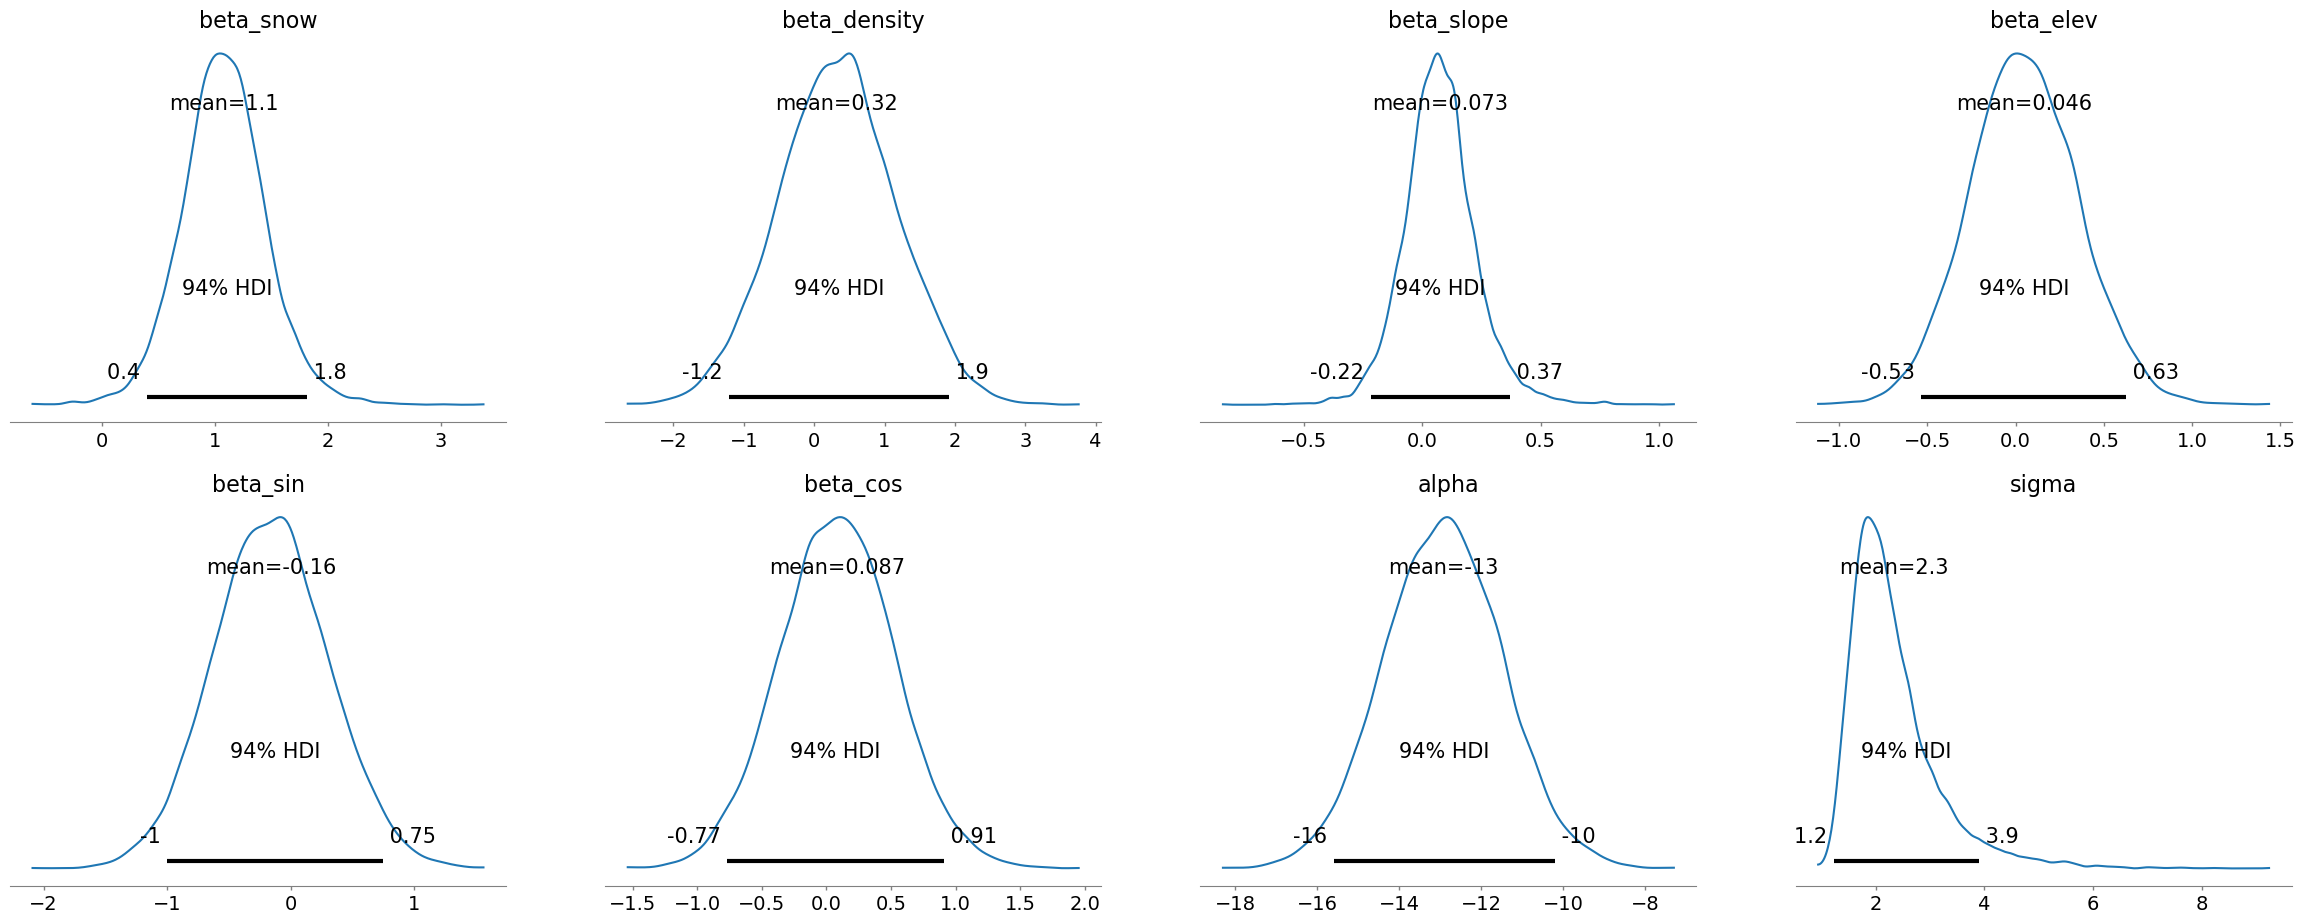

In [94]:
plot_all_posterior_coefficients(model_depth_density_topography_idata)

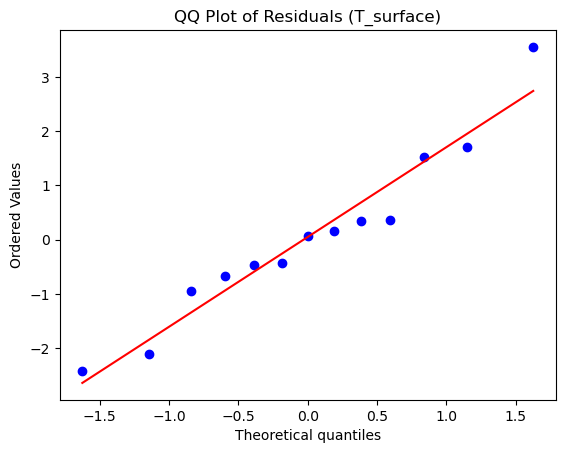

In [95]:
residuals = plot_residual_qq(
    model_depth_density_topography_idata,
    T_surface,
    var_name="T_surface"
)

In [96]:
r2_table = compute_bayesian_r2(
    model_depth_density_topography_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.499182,0.11431


In [97]:
loo_depth_density_topography = compute_loo(model_depth_density_topography_idata)
print(loo_depth_density_topography)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -29.63     2.10
p_loo        3.54        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

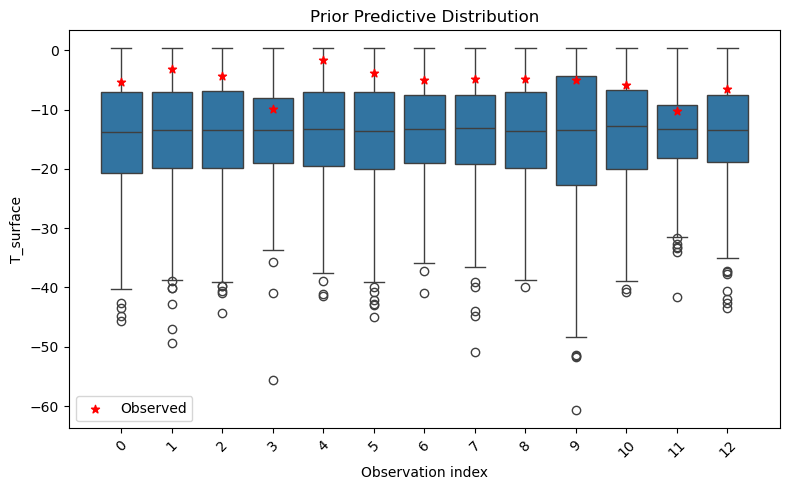

In [98]:
plot_prior_predictions(model_depth_density_topography_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

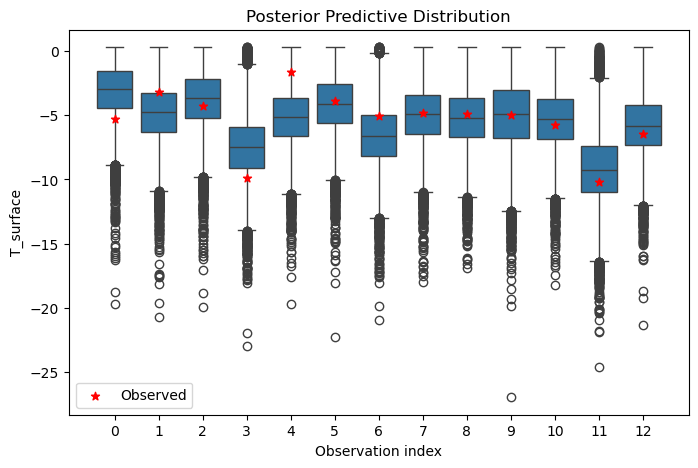

In [99]:
plot_predictions(model_depth_density_topography_idata)

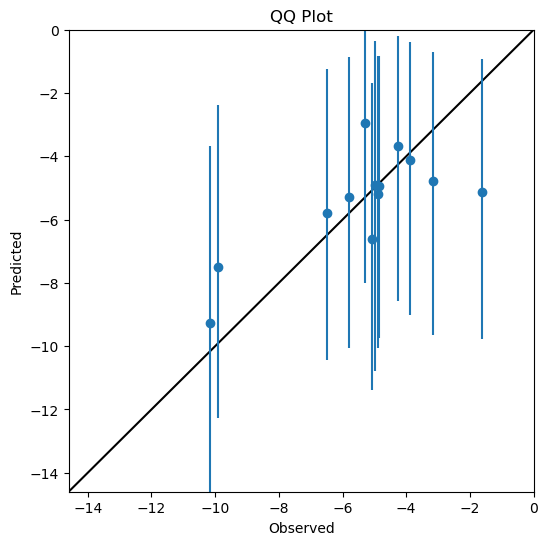

In [100]:
qqplot(model_depth_density_topography_idata)

In [101]:
models = {
    "depth": model_depth_idata,
    "density": model_density_idata,
    "depth_density": model_depth_density_idata,
    "depth_topography": model_depth_topography_idata,
    "density_topography": model_density_topography_idata,
    "depth_density_topography": model_depth_density_topography_idata,
    "topography": model_topography_idata
}



In [102]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = compute_loo(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [103]:
print(comparison_table)

                      Model   R2_mean     R2_sd   elpd_loo     p_loo    loo_se
0                     depth  0.522271  0.108259 -27.702207  2.310297  2.488880
1                   density  0.351997  0.089034 -31.901777  1.968481  2.567031
2             depth_density  0.493773  0.118142 -27.973403  2.510693  2.375725
3          depth_topography  0.504786  0.112039 -29.752719  3.682540  2.352432
4        density_topography  0.378457  0.086938 -32.921286  2.323413  2.030323
5  depth_density_topography  0.499182  0.114310 -29.632986  3.539696  2.104196
6                topography  0.382933  0.085492 -33.074046  2.152680  1.896478


In [104]:
comparison_table = comparison_table.sort_values(
    by="elpd_loo",
    ascending=False
)

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se
0,depth,0.522271,0.108259,-27.702207,2.310297,2.488880
2,depth_density,0.493773,0.118142,-27.973403,2.510693,2.375725
5,depth_density_topography,0.499182,0.114310,-29.632986,3.539696,2.104196
3,depth_topography,0.504786,0.112039,-29.752719,3.682540,2.352432
1,density,0.351997,0.089034,-31.901777,1.968481,2.567031
4,density_topography,0.378457,0.086938,-32.921286,2.323413,2.030323
6,topography,0.382933,0.085492,-33.074046,2.152680,1.896478


In [105]:
best_loo = comparison_table["elpd_loo"].max()

comparison_table["delta_elpd"] = best_loo - comparison_table["elpd_loo"]

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se,delta_elpd
0,depth,0.522271,0.108259,-27.702207,2.310297,2.488880,0.000000
2,depth_density,0.493773,0.118142,-27.973403,2.510693,2.375725,0.271196
5,depth_density_topography,0.499182,0.114310,-29.632986,3.539696,2.104196,1.930779
3,depth_topography,0.504786,0.112039,-29.752719,3.682540,2.352432,2.050512
1,density,0.351997,0.089034,-31.901777,1.968481,2.567031,4.199570
4,density_topography,0.378457,0.086938,-32.921286,2.323413,2.030323,5.219079
6,topography,0.382933,0.085492,-33.074046,2.152680,1.896478,5.371839


# Sensitivity Analysis

### Uninformed priors for model_depth

To assess the sensitivity of model results to prior specification, we evaluated models with Normal priors of standard deviation ($sigma=10$) for the predictors, while keeping the likelihood and model structure unchanged. In weakly informed models parameter uncertainty increased, with snow density in particular showing wide credible intervals spanning physically implausible values. Thus, informed prior specification provides more conservative and physically plausible estimates, motivating the use of the informed prior model as the primary analytical framework in this study.

In [106]:
T_surface = df["T_surface"].values

with pm.Model() as model_uninformed:

    # Data
    snow = pm.Data("snow", df["snow_10cm"].values)

    # Intercept (physically constrained)
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,          
        sigma=10,      
        upper=0.3
    )

    # Snow slope 
    beta_snow = pm.Normal(
        "beta_snow",
        mu=0,
        sigma=10        
    )

    # Linear predictor
    mu = alpha + beta_snow * snow

    # Residual variance
    sigma = pm.HalfNormal(
        "sigma",
        sigma=10        
    )

    # Likelihood
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [107]:
model_uninformed_prior, model_uninformed_idata = run_model(model_uninformed)

Sampling: [T_surface, alpha, beta_snow, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 80 seconds.
There were 41 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

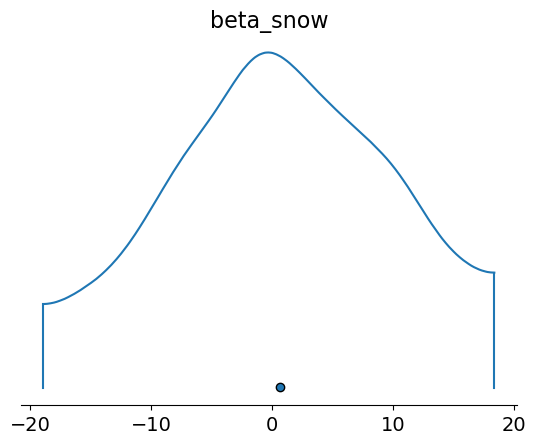

In [108]:
plot_all_prior_coefficients(model_uninformed_prior)

In [109]:
prior_summary = summarize_all_prior_coefficients(model_uninformed_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-15.10,8.50,-28.94,0.24,0.28,0.18,882.69,904.95,NaN
sigma,8.13,6.21,0.00,19.34,0.20,0.17,931.81,876.89,NaN
beta_snow,0.68,10.19,-18.97,18.44,0.31,0.25,1049.67,899.06,NaN


In [110]:
summary = summarize_all_posterior_coefficients(model_uninformed_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.44,1.40,0.19,2.65,0.06,0.25,1540.22,812.85,1.00
alpha,-12.10,3.05,-17.87,-6.59,0.07,0.10,2472.94,1992.70,1.00
sigma,2.68,2.14,1.12,4.88,0.08,0.26,1229.27,924.22,1.01


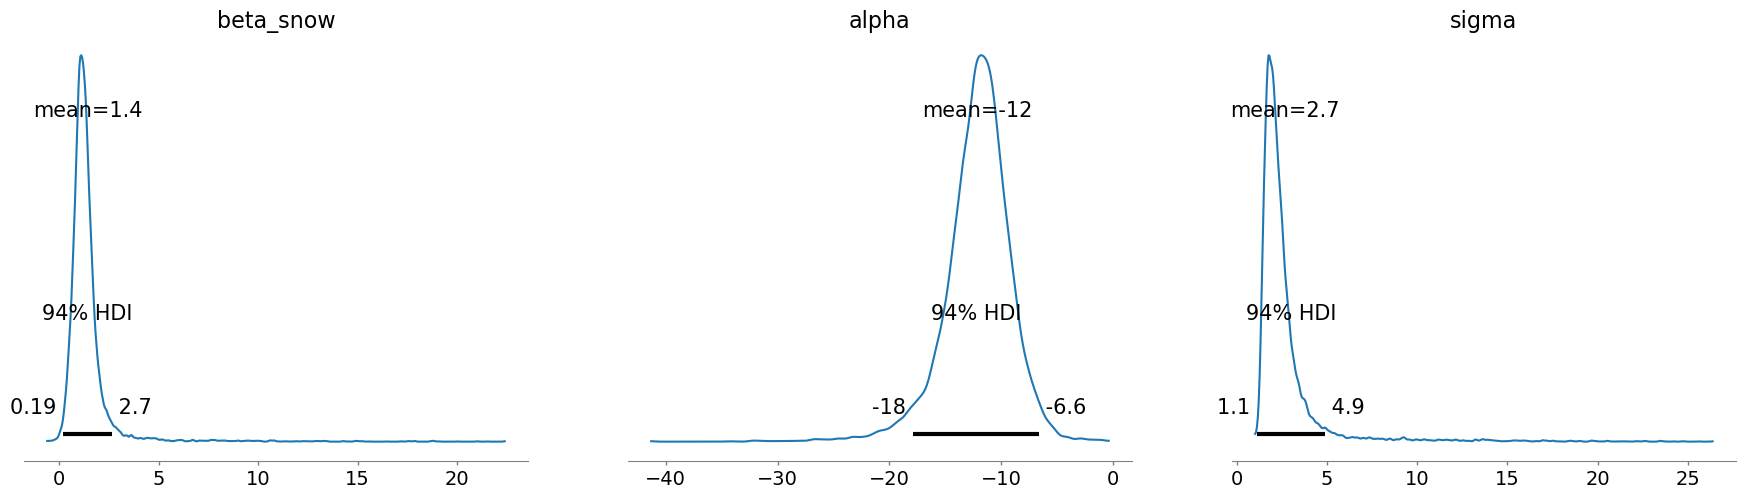

In [111]:
plot_all_posterior_coefficients(model_uninformed_idata)

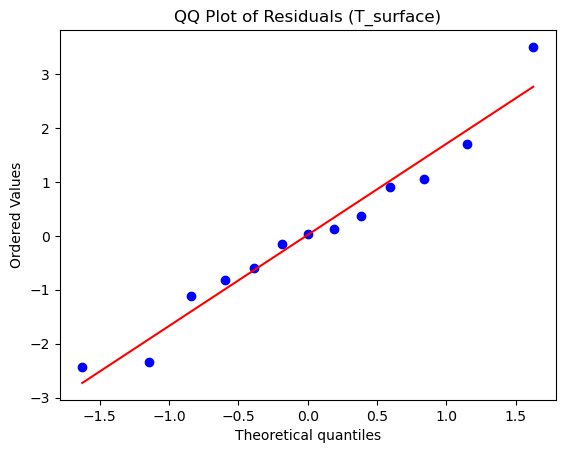

In [112]:
residuals = plot_residual_qq(
    model_uninformed_idata,
    T_surface,
    var_name="T_surface"
)

In [113]:
r2_table = compute_bayesian_r2(
    model_uninformed_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.503183,0.117689


In [114]:
loo_uninformed = compute_loo(model_uninformed_idata)
print(loo_uninformed)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -29.10     2.07
p_loo        3.02        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       13  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

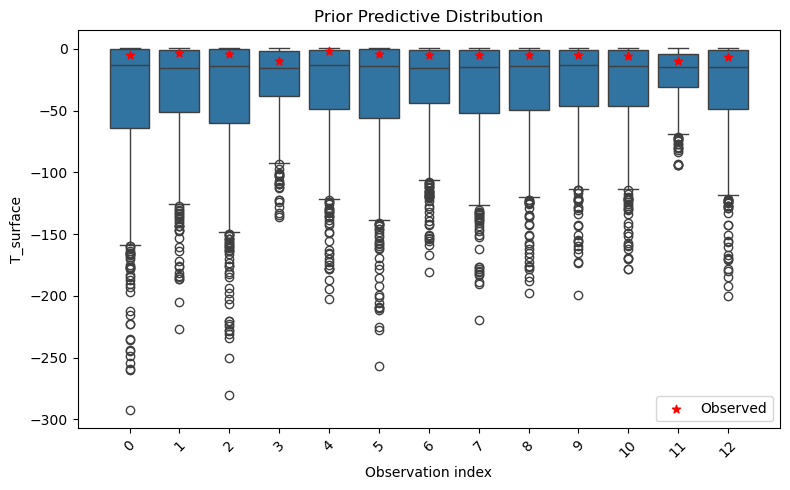

In [115]:
plot_prior_predictions(model_uninformed_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

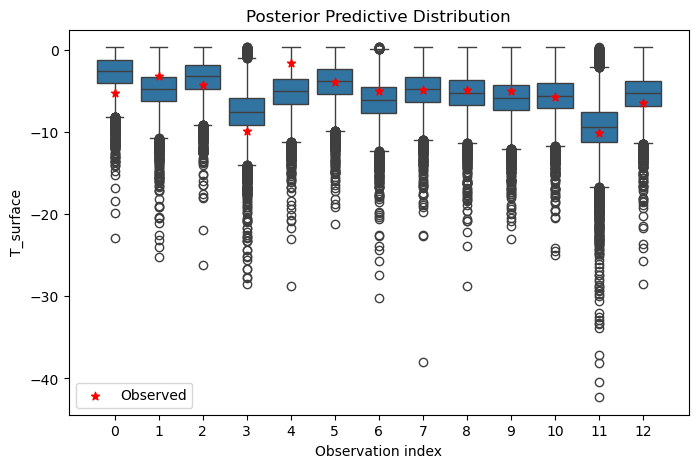

In [116]:
plot_predictions(model_uninformed_idata)

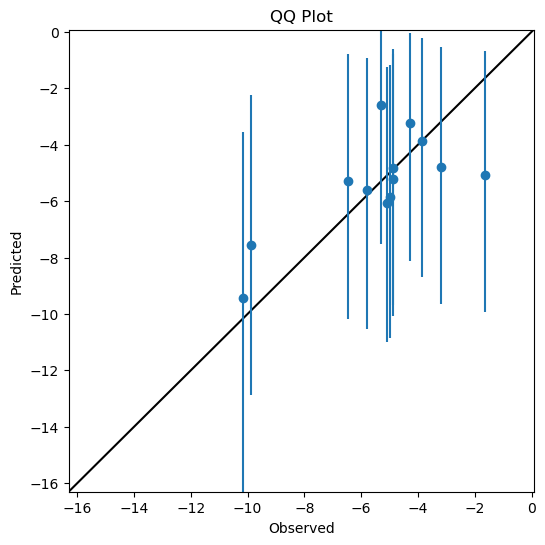

In [117]:
qqplot(model_uninformed_idata)

## Analytical Model

As a sensitivity analysis, we fitted an analytical Bayesian linear regression with conjugate priors to examine the relationship between snow depth and surface temperature. In this formulation, surface temperature was modeled as a linear function of snow depth under the assumption of Gaussian residual errors. 

The reduced predictive skill of the analytical approach likely reflects its stronger structural assumptions and limited flexibility compared to the numerically sampled MCMC framework. These results support the use of the MCMC-based models (above) as the primary analytical approach in this study.

In [118]:
y = df["T_surface"].values  # target variable
X = df[["snow_10cm"]].values  # predictor
n = len(y)

X = np.column_stack([np.ones(n), X])

# Priors: beta ~ N(mu_prior, sigma_prior^2)
mu_prior = np.array([-13.2, 0])   
sigma_prior = np.array([2.0, 2.0])
Lambda_prior = np.diag(1 / sigma_prior**2)  


In [119]:
sigma = 2.0
sigma2 = sigma**2

In [120]:
# Posterior covariance
Sigma_post = np.linalg.inv((X.T @ X) / sigma2 + Lambda_prior)

# Posterior mean
mu_post = Sigma_post @ ((X.T @ y) / sigma2 + Lambda_prior @ mu_prior)

print("Posterior mean:", mu_post)
print("Posterior covariance matrix:\n", Sigma_post)

Posterior mean: [-12.19842812   1.21950698]
Posterior covariance matrix:
 [[ 2.07806805 -0.35095039]
 [-0.35095039  0.06871756]]


In [121]:
samples = np.random.multivariate_normal(mu_post, Sigma_post, size=1000)

In [122]:
# --- Analytical posterior predictive R² ---

# Sample beta from analytical posterior
n_draws = 1000
beta_samples = np.random.multivariate_normal(mu_post, Sigma_post, size=n_draws)

# Compute R² for each draw
r2_analytical = np.zeros(n_draws)
y_true = y  # observed T_surface
y_mean = np.mean(y_true)

for i in range(n_draws):
    y_pred = X @ beta_samples[i]  # predicted T_surface for this beta sample
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_mean)**2)
    r2_analytical[i] = 1 - ss_res / ss_tot

# Summarize
r2_analytical_mean = np.mean(r2_analytical)
r2_analytical_sd = np.std(r2_analytical)
r2_analytical_ci = np.percentile(r2_analytical, [2.5, 97.5])

print("Analytical posterior predictive R²:")
print(f"Mean: {r2_analytical_mean:.3f}, SD: {r2_analytical_sd:.3f}, 95% CI: [{r2_analytical_ci[0]:.3f}, {r2_analytical_ci[1]:.3f}]")


Analytical posterior predictive R²:
Mean: 0.395, SD: 0.098, 95% CI: [0.136, 0.490]


## Vegetation influence 
model_depth grouped by vegetation 

To evaluate whether vegetation type influenced ground surface temperatures, we tested a hierarchical Bayesian model including varying intercepts for vegetation class. The model structure remained identical to the primary \textit{depth} model. 
Posterior estimates showed substantial overlap among vegetation group intercepts. Mean intercept estimates ranged from -12.8°C for dry tundra to -12.0°C for moist shrub, with overlapping highest density intervals across all groups. The estimated group-level standard deviation was relatively small 0.8°C, SD: 0.5°C, indicating limited between-group variability.
These results confirm that, within the limited environmental variability captured by the sensor network, vegetation does not emerge as a statistically identifiable control on ground surface temperature.

In [123]:
veg_codes, veg_idx = np.unique(df["vegetation"], return_inverse=True)
n_veg = len(veg_codes)

In [124]:
veg_codes

array(['dry shrub', 'dry tundra', 'moist shrub', 'moist tundra'],
      dtype=object)

0 = dry shrub
1 = dry tundra
2 = moist shrub
3 = moist tundra

In [125]:
T_surface = df["T_surface"].values

with pm.Model() as model_veg:

    # Data
    snow = pm.Data("snow", df["snow_10cm"].values)
    veg = pm.Data("veg", veg_idx)

    # Global intercept
    alpha_mu = pm.TruncatedNormal("alpha_mu", mu=-13.2, sigma=1.5, upper=0.3)

    # Between-vegetation variability
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1)

    # Vegetation-specific intercepts
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=alpha_mu,
        sigma=sigma_alpha,
        upper=0.3,
        shape=n_veg
    )

    # Snow slope (pooled)
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,        
        sigma=1
    )

    # Linear predictor
    mu = alpha[veg] + beta_snow * snow

    # Residual
    sigma = pm.HalfNormal("sigma", sigma=4)

    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )

In [126]:
model_veg_prior,model_veg_idata = run_model(model_veg)

Sampling: [T_surface, alpha, alpha_mu, beta_snow, sigma, sigma_alpha]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_mu, sigma_alpha, alpha, beta_snow, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 90 seconds.
There were 540 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

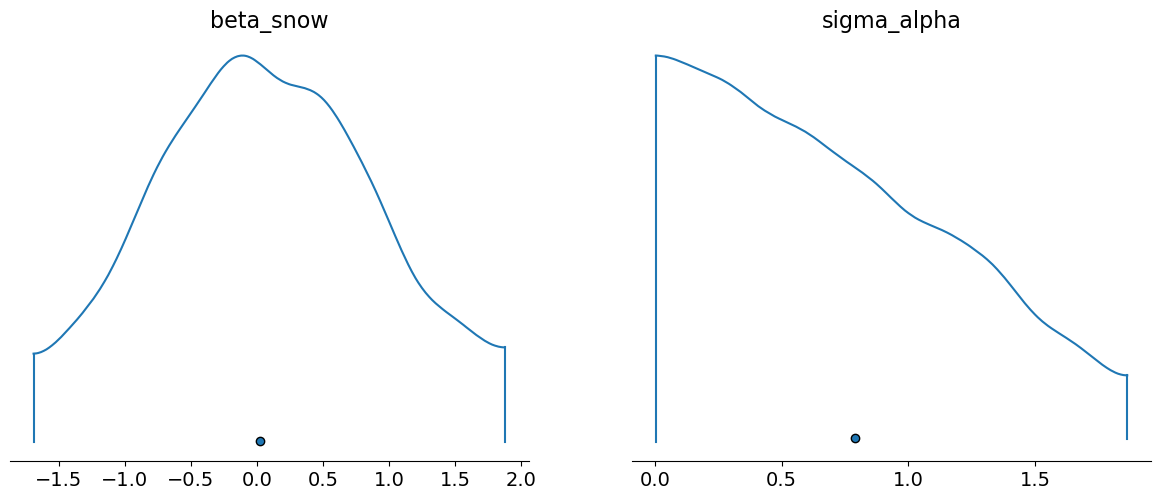

In [127]:
plot_all_prior_coefficients(model_veg_prior)

In [128]:
prior_summary = summarize_all_prior_coefficients(model_veg_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.15,2.40,0.01,7.45,0.07,0.07,1072.29,982.80,NaN
alpha[0],-13.20,1.80,-16.36,-9.73,0.06,0.04,946.87,891.23,NaN
alpha[1],-13.24,1.85,-16.65,-9.56,0.06,0.05,978.75,943.76,NaN
alpha[2],-13.20,1.80,-16.36,-9.74,0.06,0.04,940.93,933.90,NaN
alpha[3],-13.23,1.78,-16.68,-10.15,0.06,0.04,1001.09,904.74,NaN
beta_snow,0.02,0.95,-1.69,1.88,0.03,0.02,974.02,952.50,NaN
sigma_alpha,0.79,0.58,0.00,1.86,0.02,0.01,1021.42,871.56,NaN


In [129]:
summary = summarize_all_posterior_coefficients(model_veg_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.26,0.23,0.82,1.71,0.01,0.00,1710.99,1125.43,1.0
sigma_alpha,0.79,0.49,0.12,1.66,0.01,0.01,550.45,214.53,1.0
alpha[0],-12.07,1.39,-14.76,-9.54,0.03,0.02,1781.94,1680.40,1.0
alpha[1],-12.88,1.33,-15.31,-10.27,0.03,0.02,2011.82,2564.57,1.0
alpha[2],-12.03,1.35,-14.59,-9.53,0.03,0.02,1707.57,1819.01,1.0
alpha[3],-12.16,1.29,-14.52,-9.71,0.03,0.02,1766.86,1685.25,1.0
sigma,1.95,0.57,1.06,3.03,0.01,0.01,1740.08,1578.36,1.0


0 = dry shrub
1 = dry tundra
2 = moist shrub
3 = moist tundra

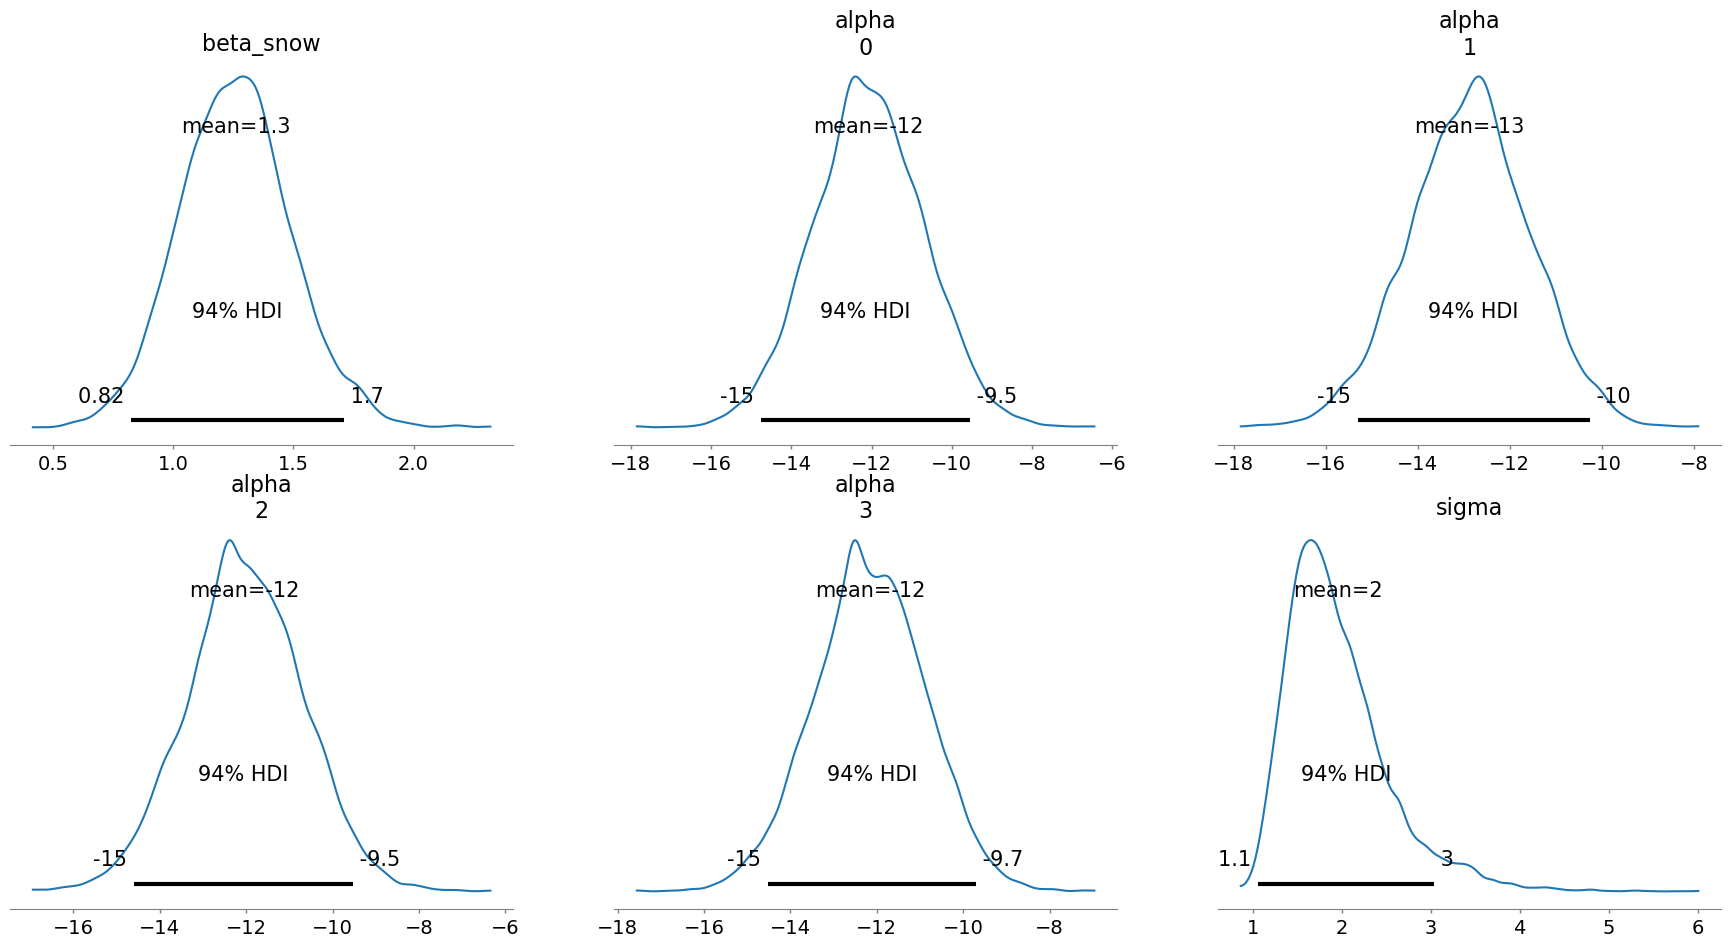

In [130]:
plot_all_posterior_coefficients(model_veg_idata)

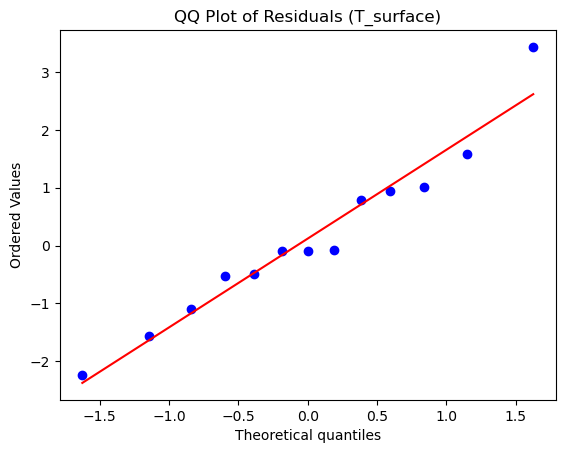

In [131]:
residuals = plot_residual_qq(
    model_veg_idata,
    T_surface,
    var_name="T_surface"
)

In [132]:
r2_table = compute_bayesian_r2(
    model_veg_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.550396,0.109412


In [133]:
loo_veg = compute_loo(model_veg_idata)
print(loo_veg)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -27.59     2.66
p_loo        3.24        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       12   92.3%
   (0.70, 1]   (bad)         1    7.7%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

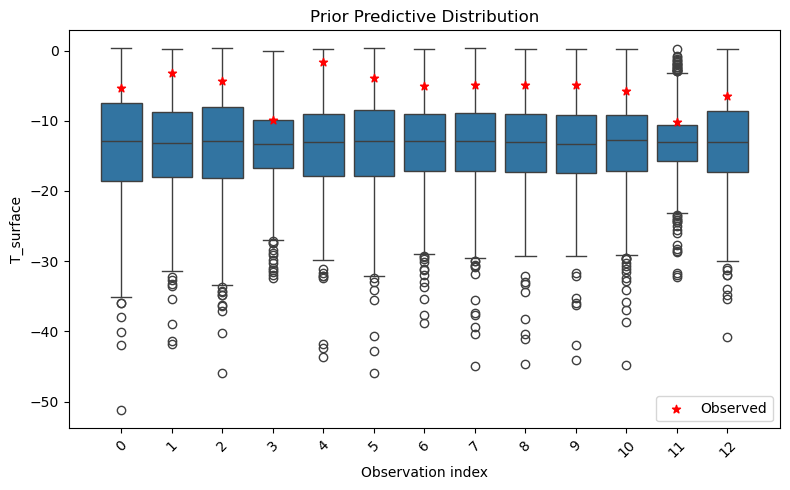

In [134]:
plot_prior_predictions(model_veg_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

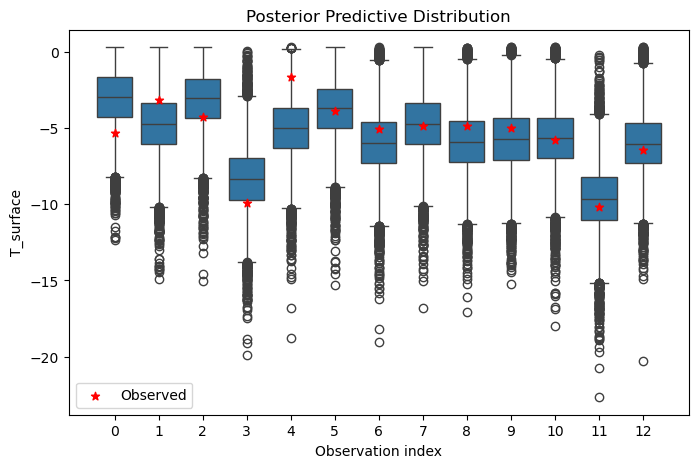

In [135]:
plot_predictions(model_veg_idata)

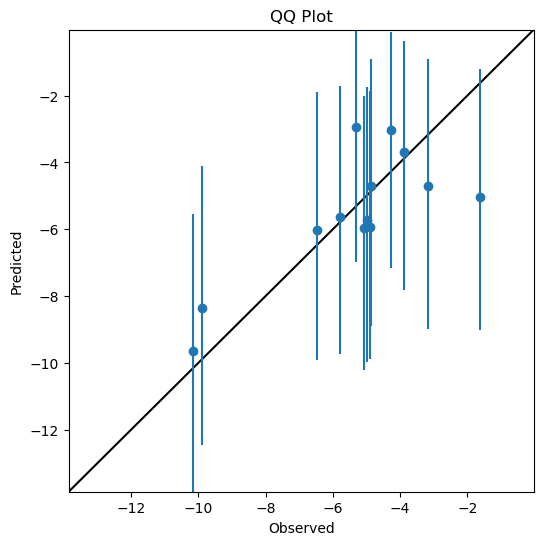

In [136]:
qqplot(model_veg_idata)

# Model comparison 

In [137]:
models = {
    "depth": model_depth_idata,
    "density": model_density_idata,
    "depth_density": model_depth_density_idata,
    "depth_topography": model_depth_topography_idata,
    "density_topography": model_density_topography_idata,
    "depth_density_topography": model_depth_density_topography_idata,
    "topography": model_topography_idata, 
    "depth_uninformed": model_uninformed_idata,
    "depth_vegetation": model_veg_idata
}



In [138]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = compute_loo(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [139]:
comparison_table = comparison_table.sort_values(
    by="elpd_loo",
    ascending=False
)

comparison_table

,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se
8,depth_vegetation,0.550396,0.109412,-27.593147,3.240520,2.657577
0,depth,0.522271,0.108259,-27.702207,2.310297,2.488880
2,depth_density,0.493773,0.118142,-27.973403,2.510693,2.375725
7,depth_uninformed,0.503183,0.117689,-29.104372,3.022139,2.066629
5,depth_density_topography,0.499182,0.114310,-29.632986,3.539696,2.104196
3,depth_topography,0.504786,0.112039,-29.752719,3.682540,2.352432
1,density,0.351997,0.089034,-31.901777,1.968481,2.567031
4,density_topography,0.378457,0.086938,-32.921286,2.323413,2.030323
6,topography,0.382933,0.085492,-33.074046,2.152680,1.896478


In [140]:
for name, idata in models.items():
    loo = az.loo(idata)
    k_vals = loo.pareto_k.values
    
    print(f"\nModel: {name}")
    print("Max k:", np.max(k_vals))
    print("k > 0.7:", np.sum(k_vals > 0.7))
    print("k > 1.0:", np.sum(k_vals > 1.0))



Model: depth
Max k: 0.5794201284444901
k > 0.7: 0
k > 1.0: 0

Model: density
Max k: 0.5315783925007003
k > 0.7: 0
k > 1.0: 0

Model: depth_density
Max k: 0.5603425062518105
k > 0.7: 0
k > 1.0: 0

Model: depth_topography
Max k: 0.9480122791297215
k > 0.7: 1
k > 1.0: 0


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



Model: density_topography
Max k: 0.6478093657766478
k > 0.7: 0
k > 1.0: 0

Model: depth_density_topography
Max k: 0.6274232076982079
k > 0.7: 0
k > 1.0: 0

Model: topography
Max k: 0.6890475507680083
k > 0.7: 0
k > 1.0: 0

Model: depth_uninformed
Max k: 0.5802090089131322
k > 0.7: 0
k > 1.0: 0

Model: depth_vegetation
Max k: 0.7815521104025135
k > 0.7: 1
k > 1.0: 0


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [141]:
models = {
    "Depth": model_depth_idata,
    "Depth+Density": model_depth_density_idata,
    "Depth+Topo": model_depth_topography_idata,
    "Depth+Density+Topo": model_depth_density_topography_idata,
    "Density": model_density_idata,
}

predictor_labels = {
    "beta_snow": "Snow depth",
    "beta_density": "Bulk density",
    "beta_slope": "Slope",
    "beta_sin": "Aspect sin",
    "beta_cos": "Aspect cos",
    "beta_elev": "Elevation"
}


In [142]:
rows = []

for model_name, idata in models.items():
    
    summary = az.summary(idata, hdi_prob=0.95)
    
    for param in summary.index:
        
        if param.startswith("beta_"):
            
            rows.append({
                "Model": model_name,
                "Predictor": predictor_labels.get(param, param),
                "Mean": summary.loc[param, "mean"],
                "Lower": summary.loc[param, "hdi_2.5%"],
                "Upper": summary.loc[param, "hdi_97.5%"]
            })

coef_df = pd.DataFrame(rows)



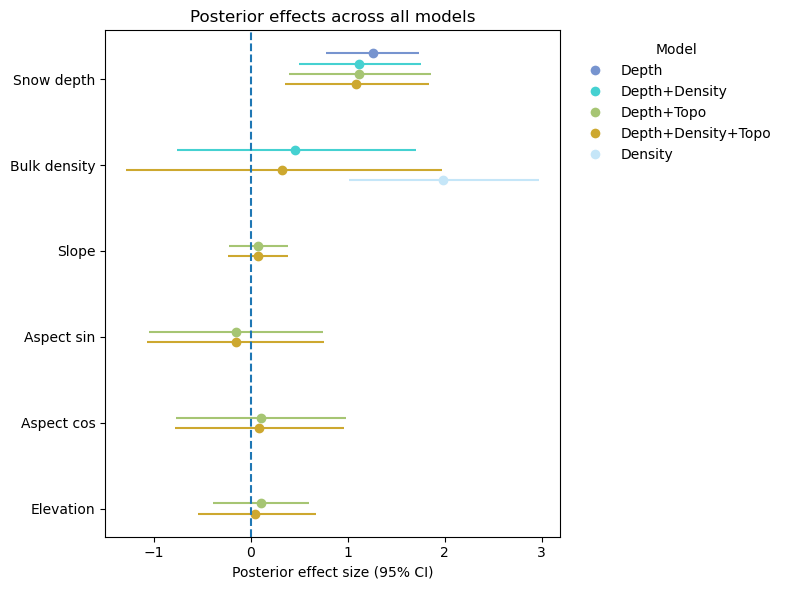

In [143]:
plt.figure(figsize=(8,6))

predictors = list(predictor_labels.values())
y_base = np.arange(len(predictors))

offset = 0.12

models_list = list(models.keys())

colors = {
    "Depth": "#7794cf",
    "Depth+Density": "#45d1d1",
    "Depth+Topo": "#a6c573",
    "Depth+Density+Topo": "#CDA82F",
    "Density": "#c5e6f8",
}

for j, predictor in enumerate(predictors):
    
    y_center = y_base[j]
    
    for i, model_name in enumerate(models_list):
        
        subset = coef_df[
            (coef_df["Model"] == model_name) &
            (coef_df["Predictor"] == predictor)
        ]
        
        if len(subset) == 0:
            continue  
        
        y_pos = y_center + (i - len(models_list)/2) * offset
        
        plt.hlines(
            y=y_pos,
            xmin=subset["Lower"].values[0],
            xmax=subset["Upper"].values[0],
            color=colors[model_name]
        )
        
        plt.plot(
            subset["Mean"].values[0],
            y_pos,
            "o",
            color=colors[model_name]
        )

plt.axvline(0, linestyle="--")
plt.yticks(y_base, predictors)
plt.gca().invert_yaxis()

plt.xlabel("Posterior effect size (95% CI)")
plt.title("Posterior effects across all models")

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[model], markersize=8,
           label=model)
    for model in models_list
]

plt.legend(
    handles=legend_elements,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Model")

plt.tight_layout()
plt.show()

Posterior mean effects and 94% highest density intervals (HDI) for all candidate
Bayesian models. Dots represent posterior means and horizontal bars indicate 94% HDIs. The col-
ors represent the different models and also illustrate which predictors were included in which model.
Positive coefficients indicate an increase in the response variable (ground surface temperature) with
increasing predictor values (i.e., a warming effect), whereas negative coefficients indicate a cooling
effect. Increased snow depth has a warming effect in all four models. Snow density only shows a
warming effect, when it is the only predictor for ground surface temperatures. Slope, aspect
and elevation effects span across positive and negative values.

# Review: Add soil moisure to the models 

Upon a reviewers suggestion we added soil moisture to our models as soil liquid water content prior to soil freezing may influence the duration of the zero-curtain period and the timing of soil cooling. We included soil moisture as an additional predictor in our depth+density+topo model, using the last available soil moisture measurement at each sensor before the soil froze. However, including soil moisture did not improve model performance or predictive skill. The estimated effect of soil moisture is 0.3°C 95% HDI: -0.3 to 0.9. 

In [145]:
df["soil_moist"] = df["soil_moisture"] / 0.1

In [146]:
T_surface = df["T_surface"].values

with pm.Model() as model_depth_density_topography_moisture:

    # -------------------------
    # Data
    # -------------------------
    snow = pm.Data("snow", df["snow_10cm"].values)      
    density = pm.Data("density", df["density_01"].values) 
    slope = pm.Data("slope", df["slope"].values)
    elev = pm.Data("elev", df["elev_10m"].values)
    asp_sin = pm.Data("asp_sin", df["aspect_sin"].values)
    asp_cos = pm.Data("asp_cos", df["aspect_cos"].values)
    soil_moist = pm.Data("soil_moist", df["soil_moist"].values)

    # -------------------------
    # Intercept
    # -------------------------
    alpha = pm.TruncatedNormal(
        "alpha",
        mu=-13.2,        
        sigma=1.5,      
        upper=0.3       
    )

    # -------------------------
    # Slopes
    # -------------------------
    beta_snow = pm.Normal(
        "beta_snow", 
        mu=0,        
        sigma=1
    )

    beta_density = pm.Normal(
        "beta_density",
        mu=0,         
        sigma=1
    )

    beta_slope = pm.Normal(
        "beta_slope",
        mu=0.0,         
        sigma=0.5       
    )

    beta_elev = pm.Normal(
        "beta_elev",
        mu=0.0,
        sigma=0.5
    )

    beta_sin = pm.Normal(
        "beta_sin",
        mu=0.0,
        sigma=0.5
    )

    beta_cos = pm.Normal(
        "beta_cos",
        mu=0.0,
        sigma=0.5
    )
    
    beta_soil_moist = pm.Normal(
        "beta_soil_moist",
        mu=0.0, 
        sigma=0.5
    )

    # -------------------------
    # Residual standard deviation
    # -------------------------
    sigma = pm.HalfNormal(
        "sigma",
        sigma=4   
    )

    # -------------------------
    # Linear predictor
    # -------------------------
    mu = (
        alpha
        + beta_snow * snow
        + beta_density * density
        + beta_slope * slope
        + beta_elev * elev
        + beta_sin * asp_sin
        + beta_cos * asp_cos
        + beta_soil_moist * soil_moist
    )

    # -------------------------
    # Likelihood (truncated at upper bound 0.3°C)
    # -------------------------
    T_obs = pm.TruncatedNormal(
        "T_surface",
        mu=mu,
        sigma=sigma,
        upper=0.3,
        observed=T_surface
    )


In [147]:
model_depth_density_topography_moisture_prior, model_depth_density_topography_moisture_idata = run_model(model_depth_density_topography_moisture)

Sampling: [T_surface, alpha, beta_cos, beta_density, beta_elev, beta_sin, beta_slope, beta_snow, beta_soil_moist, sigma]
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_snow, beta_density, beta_slope, beta_elev, beta_sin, beta_cos, beta_soil_moist, sigma]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 189 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
Sampling: [T_surface]


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

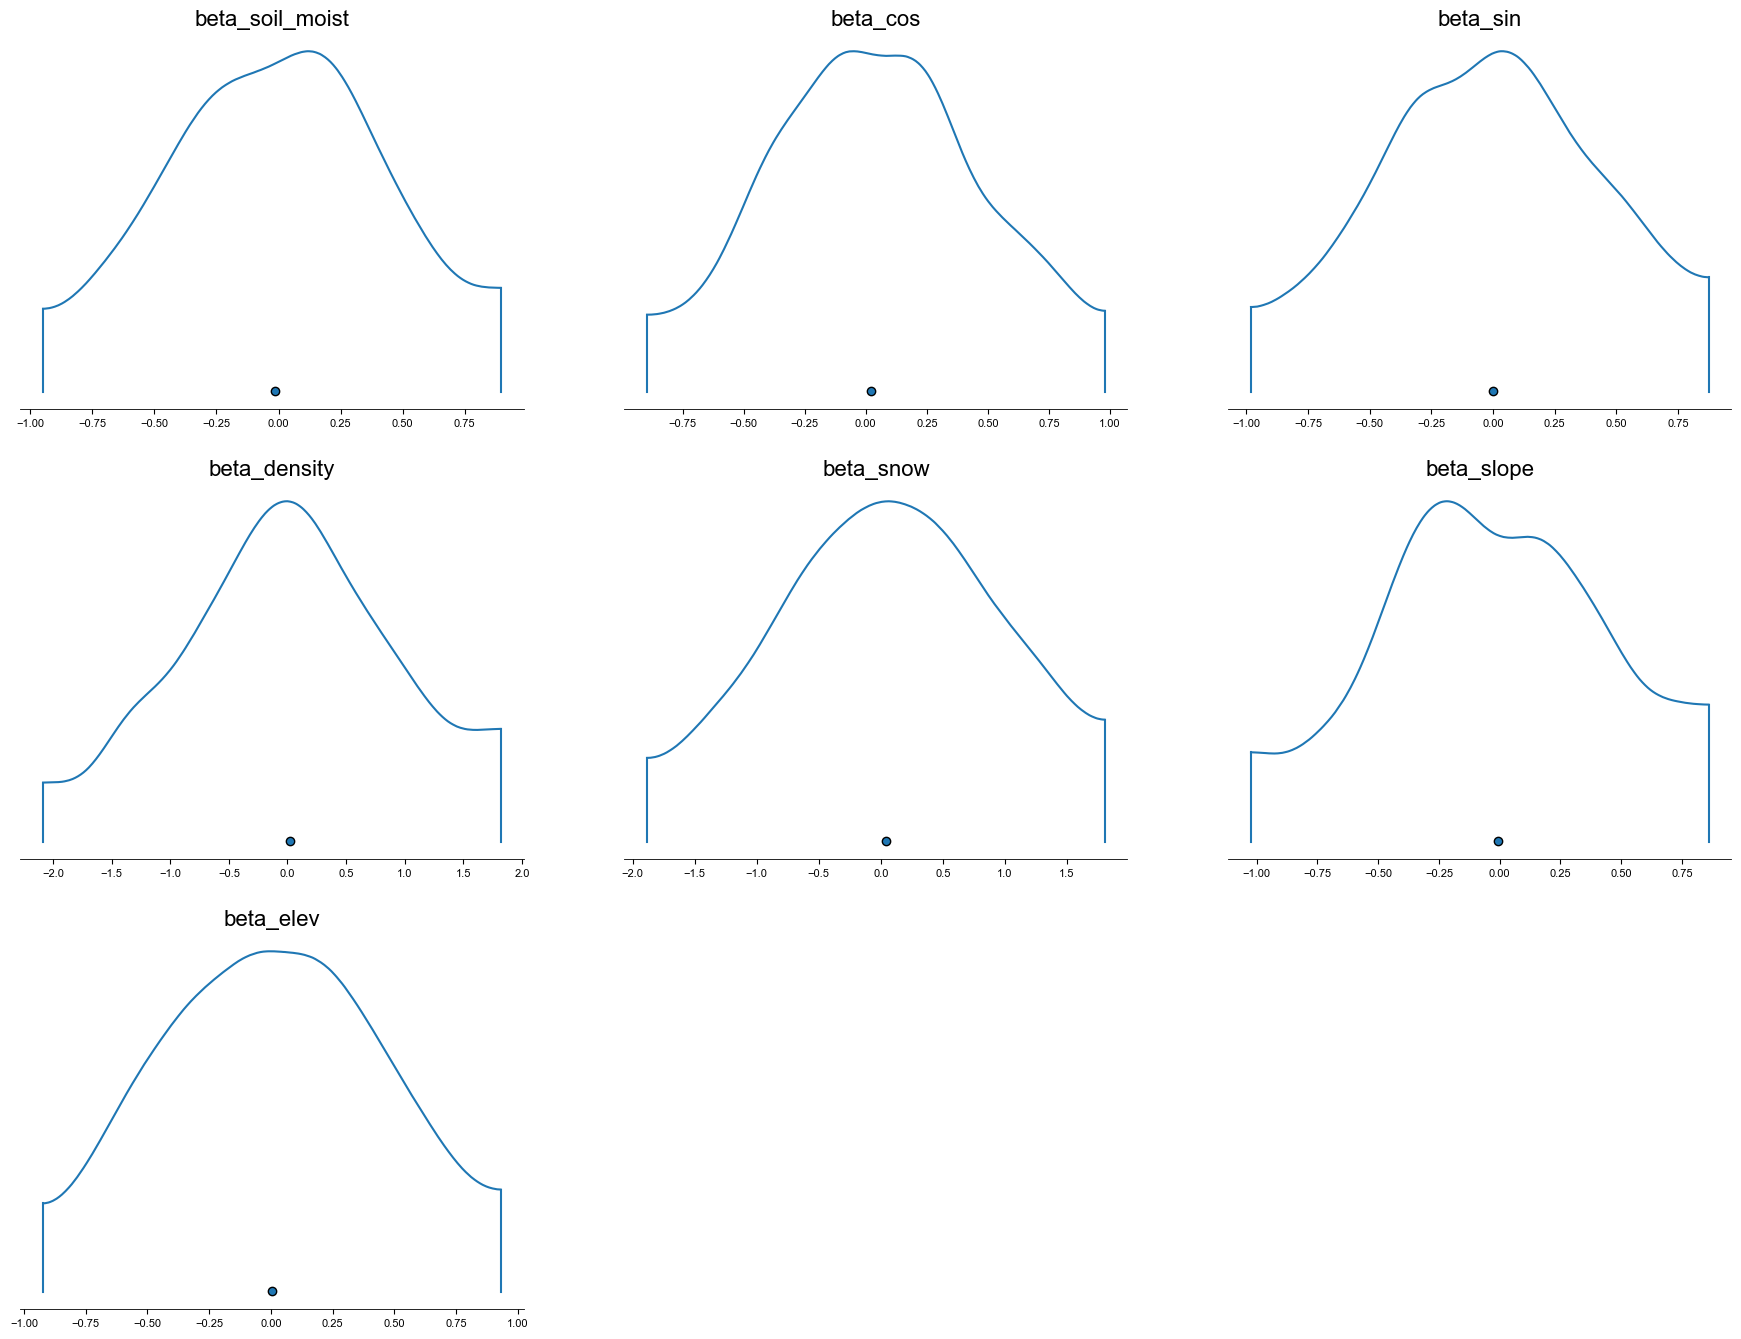

In [148]:
plot_all_prior_coefficients(model_depth_density_topography_moisture_prior)

In [149]:
prior_summary = summarize_all_prior_coefficients(model_depth_density_topography_moisture_prior)
prior_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_soil_moist,-0.01,0.49,-0.95,0.90,0.02,0.01,998.57,977.02,NaN
beta_cos,0.02,0.49,-0.90,0.98,0.02,0.01,950.60,737.55,NaN
sigma,3.16,2.37,0.00,7.35,0.08,0.07,910.18,888.89,NaN
beta_sin,-0.00,0.50,-0.98,0.88,0.02,0.01,913.19,876.32,NaN
beta_density,0.02,1.02,-2.09,1.82,0.03,0.02,939.45,818.66,NaN
alpha,-13.21,1.52,-16.06,-10.46,0.05,0.04,1062.18,902.44,NaN
beta_snow,0.04,1.00,-1.89,1.81,0.03,0.02,1011.79,972.48,NaN
beta_slope,-0.01,0.51,-1.03,0.86,0.02,0.01,832.53,842.07,NaN
beta_elev,0.00,0.50,-0.92,0.93,0.02,0.01,848.30,950.06,NaN


In [150]:
summary = summarize_all_posterior_coefficients(model_depth_density_topography_moisture_idata)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_snow,1.04,0.37,0.36,1.75,0.00,0.00,9763.50,7042.02,1.0
beta_density,0.11,0.83,-1.50,1.62,0.01,0.01,9481.98,8653.96,1.0
beta_slope,0.08,0.15,-0.22,0.36,0.00,0.00,8017.46,5382.74,1.0
beta_elev,0.02,0.31,-0.54,0.63,0.00,0.00,7498.53,7135.91,1.0
beta_sin,-0.18,0.46,-1.04,0.69,0.00,0.00,13598.91,8453.16,1.0
beta_cos,0.06,0.44,-0.76,0.90,0.00,0.00,12855.40,8602.09,1.0
beta_soil_moist,0.34,0.34,-0.27,1.00,0.00,0.00,13016.72,8546.93,1.0
alpha,-13.07,1.44,-15.90,-10.49,0.01,0.01,11127.09,7641.21,1.0
sigma,2.22,0.79,1.13,3.65,0.01,0.02,5744.78,5245.04,1.0


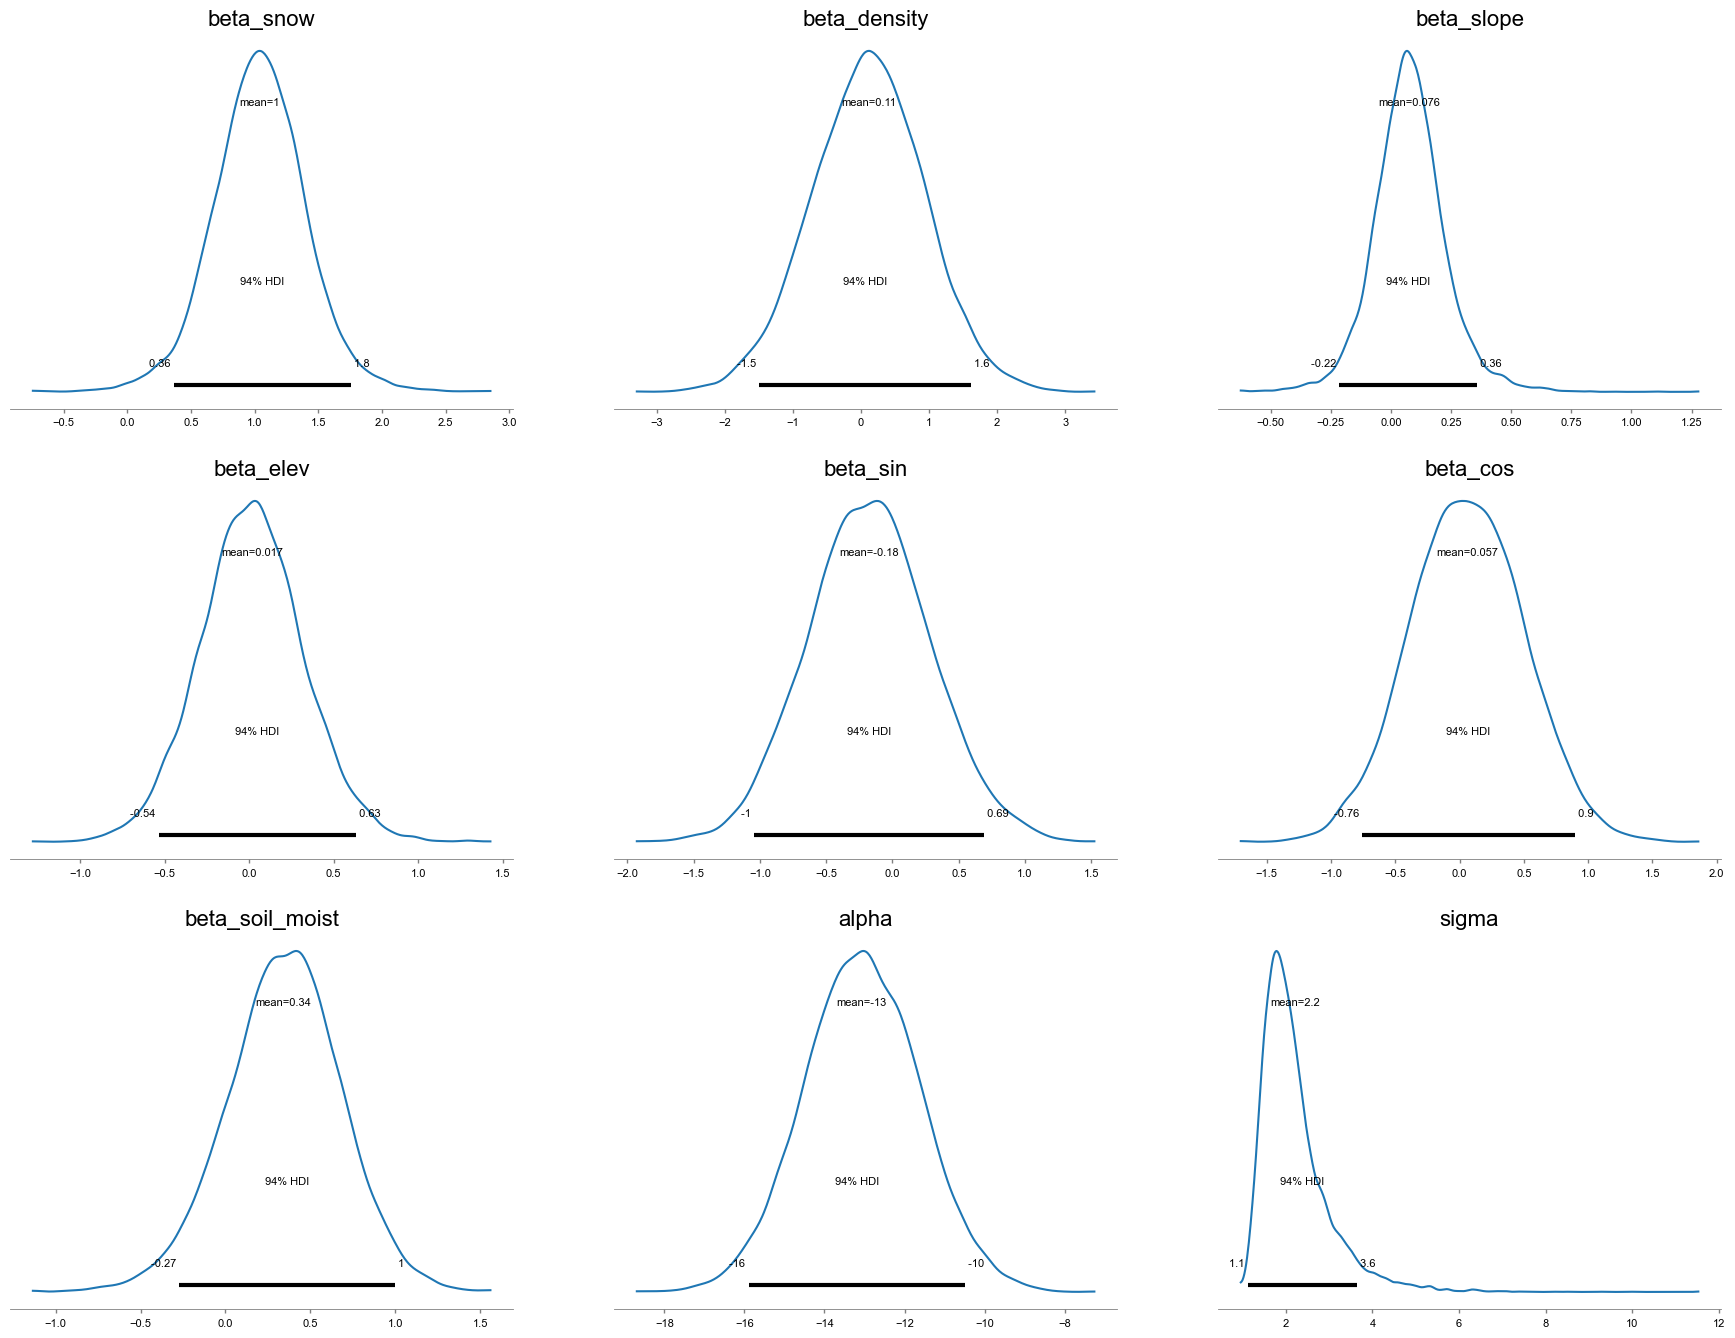

In [151]:
plot_all_posterior_coefficients(model_depth_density_topography_moisture_idata)

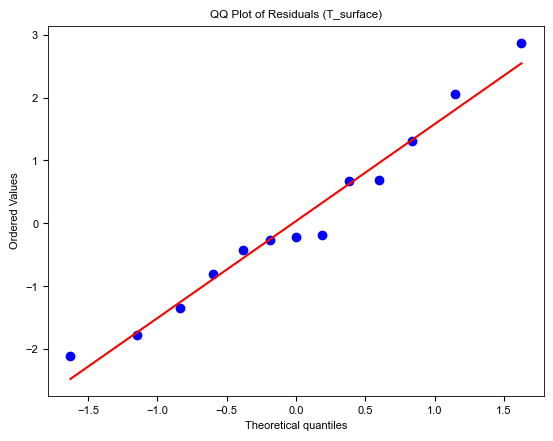

In [152]:
residuals = plot_residual_qq(
    model_depth_density_topography_moisture_idata,
    T_surface,
    var_name="T_surface"
)

In [153]:
r2_table = compute_bayesian_r2(
    model_depth_density_topography_moisture_idata,
    T_surface
)
r2_table


,R2_mean,R2_sd
0,0.516658,0.116113


In [154]:
loo_depth_density_topography_moisture = compute_loo(model_depth_density_topography_moisture_idata)
print(loo_depth_density_topography_moisture)

Computed from 12000 posterior samples and 13 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -29.37     1.61
p_loo        4.04        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       10   76.9%
   (0.70, 1]   (bad)         3   23.1%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Prior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

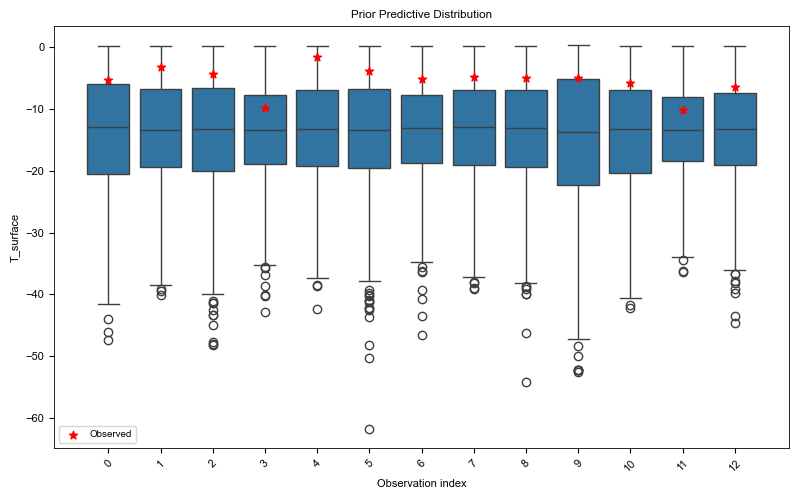

In [155]:
plot_prior_predictions(model_depth_density_topography_moisture_prior, var="T_surface")

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Posterior Predictive Distribution'}, xlabel='Observation index', ylabel='T_surface'>)

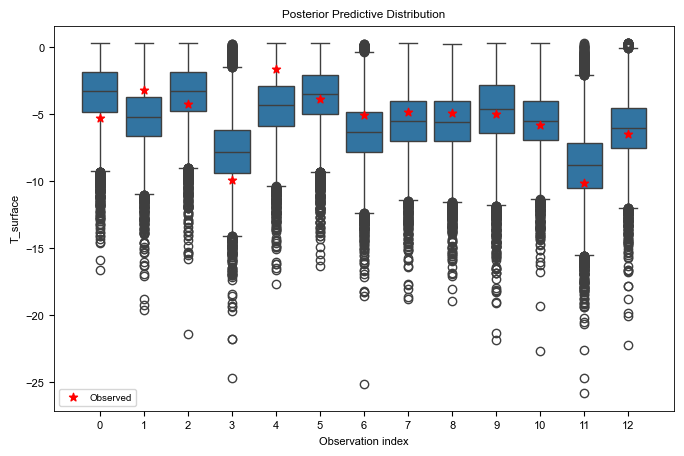

In [156]:
plot_predictions(model_depth_density_topography_moisture_idata)

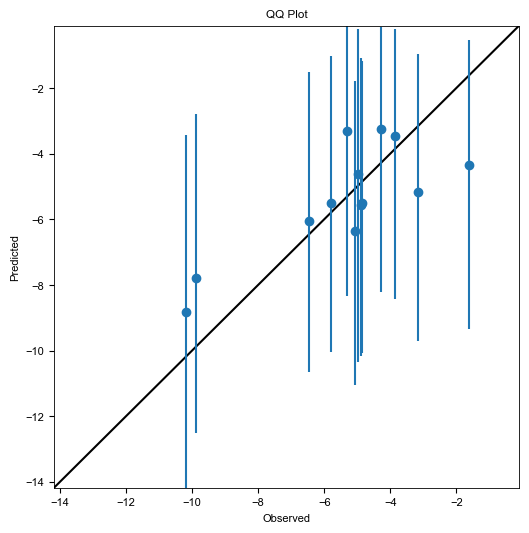

In [157]:
qqplot(model_depth_density_topography_moisture_idata)

# Model summary

In [158]:
models = {
    "depth": model_depth_idata,
    "density": model_density_idata,
    "depth_density": model_depth_density_idata,
    "depth_topography": model_depth_topography_idata,
    "density_topography": model_density_topography_idata,
    "depth_density_topography": model_depth_density_topography_idata,
    "topography": model_topography_idata,
    "depth_density_topography_moisture":model_depth_density_topography_moisture_idata 
}



In [159]:
comparison_results = []

for name, idata in models.items():
    
    # R²
    r2 = compute_bayesian_r2(idata, T_surface)
    r2_mean = float(r2["R2_mean"].values[0])
    r2_sd   = float(r2["R2_sd"].values[0])
    
    # LOO
    loo = compute_loo(idata)
    
    comparison_results.append({
        "Model": name,
        "R2_mean": r2_mean,
        "R2_sd": r2_sd,
        "elpd_loo": loo.elpd_loo,
        "p_loo": loo.p_loo,
        "loo_se": loo.se
    })

comparison_table = pd.DataFrame(comparison_results)


c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
c:\Users\sobaur001\AppData\Local\miniforge3\envs\pymc311\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [160]:
comparison_table = comparison_table.sort_values(
    by="elpd_loo",
    ascending=False
)

comparison_table


,Model,R2_mean,R2_sd,elpd_loo,p_loo,loo_se
0,depth,0.522271,0.108259,-27.702207,2.310297,2.488880
2,depth_density,0.493773,0.118142,-27.973403,2.510693,2.375725
7,depth_density_topography_moisture,0.516658,0.116113,-29.366867,4.037822,1.611851
5,depth_density_topography,0.499182,0.114310,-29.632986,3.539696,2.104196
3,depth_topography,0.504786,0.112039,-29.752719,3.682540,2.352432
1,density,0.351997,0.089034,-31.901777,1.968481,2.567031
4,density_topography,0.378457,0.086938,-32.921286,2.323413,2.030323
6,topography,0.382933,0.085492,-33.074046,2.152680,1.896478
